# Agent 03 Monitor Coverage and Stats (V2 Clean)

Notebook operativo limpio para la corrida actual:

1. Selecciona `RUN_DIR` m?s reciente.
2. Ejecuta `036_agent3_quotes_coverage_and_causes.py` (cobertura + causas, incluyendo operativas basadas en manifest del lote).
3. Ejecuta `037_agent3_diagnostics_tables_hist.py` (tablas de diagn?stico + leyenda + causas globales).
4. Ejecuta `038_bid_ask_cross_deviation_metrics.py` (m?tricas de desviaci?n `bid>ask` y granularidad cerca de 0).

Regla: todo se eval?a sobre la misma corrida (`RUN_DIR`).

In [17]:
from pathlib import Path

BASE = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit")
RUN_ID = "20260313_quotes_prod_full_12133_clean"
RUN_DIR = BASE / RUN_ID

QUOTES_ROOT = Path(r"D:\quotes")
EVENTS_CSV = RUN_DIR / "quotes_agent_strict_events_current.csv"
RETRY_QUEUE_CSV = RUN_DIR / "retry_queue_quotes_strict_current.csv"
RETRY_FROZEN_CSV = RUN_DIR / "retry_frozen_quotes_strict.csv"
BATCH_MANIFEST_CSV = RUN_DIR / "batch_manifest_quotes_strict.csv"
RUN_CONFIG_JSON = RUN_DIR / "run_config_quotes_strict.json"

OFFICIAL_LIFECYCLE_CSV = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_lifecycle_compiled.csv")
OUT_DIR = RUN_DIR / "agent03_outputs"

MIN_COVERAGE_TO_PASS = 0.95
COVERAGE_OK_STATUSES = ["PASS", "SOFT_FAIL"]
USE_BATCH_MANIFEST = False
ACCEPT_ALL_RAW = True

print("RUN_DIR:", RUN_DIR)
print("QUOTES_ROOT:", QUOTES_ROOT)
print("EVENTS_CSV exists:", EVENTS_CSV.exists())
print("RETRY_QUEUE_CSV exists:", RETRY_QUEUE_CSV.exists())
print("RETRY_FROZEN_CSV exists:", RETRY_FROZEN_CSV.exists())
print("BATCH_MANIFEST_CSV exists:", BATCH_MANIFEST_CSV.exists())
print("RUN_CONFIG_JSON exists:", RUN_CONFIG_JSON.exists())
print("OUT_DIR exists:", OUT_DIR.exists())
print("USE_BATCH_MANIFEST:", USE_BATCH_MANIFEST)
print("ACCEPT_ALL_RAW:", ACCEPT_ALL_RAW)

RUN_DIR: C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean
QUOTES_ROOT: D:\quotes
EVENTS_CSV exists: True
RETRY_QUEUE_CSV exists: True
RETRY_FROZEN_CSV exists: True
BATCH_MANIFEST_CSV exists: True
RUN_CONFIG_JSON exists: True
OUT_DIR exists: True
USE_BATCH_MANIFEST: False
ACCEPT_ALL_RAW: True


## Paso 1: Cobertura y Causas (036)

Genera artefactos base en `OUT_DIR`:
- `coverage_by_ticker.csv`
- `quality_summary_by_ticker.csv`
- `causes_by_ticker.csv`
- `ticker_diagnosis.csv`
- `run_summary.json`

**Importante sobre nombres:**

`retry_pending` y `retry_frozen_exhausted` se conservan como **nombres legacy** por compatibilidad con scripts y artefactos ya existentes.

En esta corrida de produccion su semantica correcta es:
- `retry_pending` = **review_queue_pending**
- `retry_frozen_exhausted` = **review_queue_frozen_after_max_attempts**

Es decir: no significan ?dataset rechazado?. Significan ?archivo aceptado en el bruto, pero pendiente de revision/remediacion posterior y posible lista roja?.



In [18]:
from pathlib import Path

'''036 
genera los artefactos base que consumen 037 y parte de 038:
  - coverage_by_ticker.csv
  - quality_summary_by_ticker.csv
  - causes_by_ticker.csv
  - ticker_diagnosis.csv
  - run_summary.json
037 solo visualiza/explica esos outputs; 
si no ejecutas 036 antes, faltan archivos y falla o muestra datos viejos.
'''
DIAG_HEAD_N = 3
DIAG_TRANSPOSE = True
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\036_agent3_quotes_coverage_and_causes.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

Run summary:
{
  "events_rows_dedup": 328405,
  "tickers": 259,
  "retry_pending_files": 133886,
  "review_queue_pending_files": 133886,
  "hard_fail_files": 121,
  "review_queue_semantics": "accept_all_raw_then_review_and_redlist",
  "mean_coverage_ok": 0.41241818351695,
  "gate_status": "NO_CLOSE_RETRY_PENDING",
  "acceptance_policy": "ACCEPT_ALL_RAW_REVIEW_LATER",
  "raw_dataset_status": "RAW_ACCEPTED_REVIEW_PENDING",
  "min_coverage_to_pass": 0.95,
  "out_dir": "C:\\TSIS_Data\\v1\\backtest_SmallCaps\\runs\\polygon_realtime_audit\\20260313_quotes_prod_full_12133_clean\\agent03_outputs"
}

Ticker diagnosis (por que no pasa):


,134,68,74
ticker,ARR,ALIT,ALT
ticker_gate_status,LOW_COVERAGE,NO_CLOSE_RETRY_PENDING,NO_CLOSE_RETRY_PENDING
ticker_review_status,REVIEW_PENDING_LOW_COVERAGE,REVIEW_PENDING_RETRY,REVIEW_PENDING_RETRY
backtest_ml_ready,False,False,False
exp_min,2020-01-28 00:00:00,2021-07-06 00:00:00,2017-05-05 00:00:00
exp_max,2020-02-27 00:00:00,2021-07-06 00:00:00,2017-05-05 00:00:00
expected_days,31,1,1
present_days,22,1,1
present_ok_days,22,0,0
missing_days_ok,9,1,1



Top causas globales:


,cause,cause_type,count,definicion
5,retry_pending,operational,133886,Archivo en cola de revision posterior (legacy ...
3,crossed_rows_present_but_under_threshold,warn,127657,"Hay bid>ask, pero por debajo del umbral."
2,crossed_ratio_gt_threshold,issue,13781,Porcentaje de bid>ask supera el umbral estricto.
4,retry_frozen_exhausted,operational,7552,Archivo en cola de revision agotada (legacy re...
1,crossed_ratio_gt_hard_cap,issue,3068,NaN
0,ask_integer_with_crossed_anomaly,issue,13,NaN


## Paso 2: Diagn?stico Visual (037)

Imprime:
- leyenda de causas
- resumen por severidad
- tabla de diagn?stico por ticker
- tabla de cobertura temporal
- histograma de causas globales

RUN_CONFIG_JSON exists: True

Leyenda de causas:


,cause,tipo,definicion
0,parquet_unreadable,HARD_FAIL,El parquet no se puede abrir/leer.
1,zero_byte_file,HARD_FAIL,Archivo de 0 bytes.
2,invalid_partition_path,HARD_FAIL,Ruta no cumple patron ticker/year/month/day/quotes.parquet.
3,zero_rows,HARD_FAIL,Parquet leido pero sin filas.
4,missing_required_columns,HARD_FAIL,Faltan columnas requeridas del esquema estricto.
5,negative_prices_any_row,HARD_FAIL,Hay filas con bid/ask negativos.
6,crossed_ratio_gt_threshold,HARD_FAIL,Porcentaje de bid>ask supera el umbral estricto.
7,crossed_ratio_gt_hard_cap,HARD_FAIL,Porcentaje de bid>ask supera el hard cap operativo.
8,ask_integer_with_crossed_anomaly,HARD_FAIL,ask_price enterizado masivamente junto con cruces bid>ask altos.
9,dtype_mismatch,SOFT_FAIL,Tipo de dato distinto al esperado.



Resumen por severidad (events):


,severity,count
0,HARD_FAIL,13781
1,PASS,186967
2,SOFT_FAIL,127657


Agente 02 en 032 cubrio MAX_FILES = 13727, files cubiertos/encontrados = 13727, en un total de tickers = 103.
Salida truncada a head(10).

Ticker diagnosis (por que no pasa):

Leyenda de ticker diagnosis (atributos):
- ticker : Simbolo del activo.
- ticker_gate_status : Estado de cierre por ticker (PASSING, LOW_COVERAGE, NO_CLOSE_RETRY_PENDING, NO_CLOSE_HARD_FAIL_PRESENT).
- RETRY_PENDING : Numero de archivos/dias del ticker pendientes de reintento.
- HARD_FAIL : Numero de archivos/dias con fallo duro en la validacion.
- SOFT_FAIL : Numero de archivos/dias con fallo suave en la validacion.
- cause : Causa principal asociada al ticker en el snapshot actual.
- count : Conteo de ocurrencias de la causa principal para ese ticker.
- definicion : Definicion tecnica de la causa principal.


,ticker,ticker_gate_status,RETRY_PENDING,HARD_FAIL,SOFT_FAIL,cause,count,definicion
134,ARR,LOW_COVERAGE,0,0,2,crossed_rows_present_but_under_threshold,2.0,"Hay bid>ask, pero por debajo del umbral."
0,AABA,NO_CLOSE_RETRY_PENDING,2,0,558,crossed_rows_present_but_under_threshold,560.0,"Hay bid>ask, pero por debajo del umbral."
1,AAT,NO_CLOSE_RETRY_PENDING,1438,2,194,crossed_rows_present_but_under_threshold,1535.0,"Hay bid>ask, pero por debajo del umbral."
2,ABAT,NO_CLOSE_RETRY_PENDING,144,1,188,crossed_rows_present_but_under_threshold,332.0,"Hay bid>ask, pero por debajo del umbral."
3,ABCL,NO_CLOSE_RETRY_PENDING,443,0,361,crossed_rows_present_but_under_threshold,803.0,"Hay bid>ask, pero por debajo del umbral."
4,ABEO,NO_CLOSE_RETRY_PENDING,360,0,204,crossed_rows_present_but_under_threshold,563.0,"Hay bid>ask, pero por debajo del umbral."
5,ABLV,NO_CLOSE_RETRY_PENDING,55,7,6,retry_pending,55.0,Archivo en cola de revision posterior (legacy ...
6,ABOS,NO_CLOSE_RETRY_PENDING,280,0,30,crossed_rows_present_but_under_threshold,309.0,"Hay bid>ask, pero por debajo del umbral."
7,ABR,NO_CLOSE_RETRY_PENDING,299,0,113,crossed_rows_present_but_under_threshold,406.0,"Hay bid>ask, pero por debajo del umbral."
8,ABSI,NO_CLOSE_RETRY_PENDING,350,0,139,crossed_rows_present_but_under_threshold,489.0,"Hay bid>ask, pero por debajo del umbral."



Cobertura temporal por ticker:

Leyenda de cobertura (atributos):
- ticker : Simbolo del activo.
- exp_min : Inicio de ventana esperada del ticker (lifecycle oficial acotado por observado).
- exp_max : Fin de ventana esperada del ticker (lifecycle oficial acotado por observado).
- expected_days : Dias esperados dentro de [exp_min, exp_max].
- present_days : Dias con archivo/evento presente para el ticker en la corrida analizada.
- present_ok_days : Dias presentes cuyo estado cuenta como cobertura valida (segun COVERAGE_OK_STATUSES).
- missing_days_ok : Dias faltantes para cobertura valida: expected_days - present_ok_days. Mide faltantes de dias OK, no archivo faltante en disco.
- coverage_ratio_ok : Ratio de cobertura valida: present_ok_days / expected_days.
Salida truncada a head(10).


,ticker,exp_min,exp_max,expected_days,present_days,present_ok_days,missing_days_ok,coverage_ratio_ok
68,ALIT,2021-07-06,2021-07-06,1,1,0,1,0.000000
74,ALT,2017-05-05,2017-05-05,1,1,0,1,0.000000
87,AMPX,2022-09-15,2022-09-15,1,1,0,1,0.000000
231,BKSY,2021-09-10,2021-09-10,1,1,0,1,0.000000
246,BNAI,2024-03-15,2024-03-15,1,1,0,1,0.000000
252,BNZI,2023-12-15,2023-12-15,1,1,0,1,0.000000
224,BINI,2025-07-28,2025-10-10,75,54,1,74,0.013333
46,AHCO,2019-11-11,2020-01-21,72,48,1,71,0.013889
194,BBCP,2018-12-07,2019-02-26,82,54,3,79,0.036585
250,BNKK,2025-10-10,2025-11-03,25,17,1,24,0.040000



Leyenda Top 10 causas globales de error (MAX_FILES = 13727):

                                   cause  count                                                                                                                              definicion
                           retry_pending 133886                                                                                  Archivo pendiente de reintento en retry_queue_current.
crossed_rows_present_but_under_threshold 127657                                                                 Hay bid>ask, pero por debajo del umbral. Umbral usado en corrida: 0.8%.
              crossed_ratio_gt_threshold  13781                                                         Porcentaje de bid>ask supera el umbral estricto. Umbral usado en corrida: 0.8%.
                  retry_frozen_exhausted   7552                                                                                     Archivo congelado por superar maximo de reintentos.
               cr

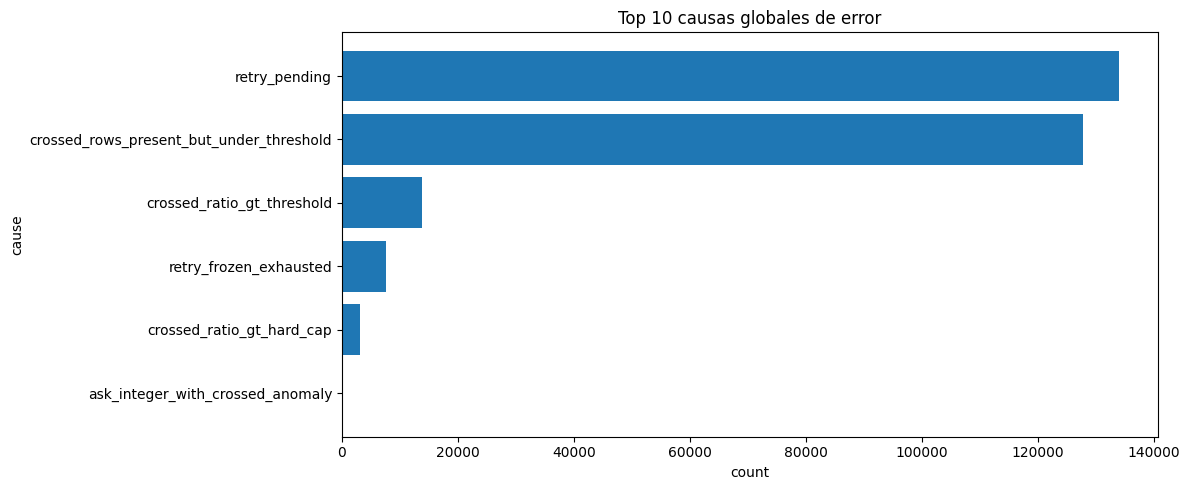


DESGLOSE GRANULADO POR TIPO DE CAUSA:


Leyenda de causas (retry_pending granulado) (MAX_FILES = 13727):

                                   cause  count                                                                      definicion
crossed_rows_present_but_under_threshold    132         Hay bid>ask, pero por debajo del umbral. Umbral usado en corrida: 0.8%.
              crossed_ratio_gt_threshold      4 Porcentaje de bid>ask supera el umbral estricto. Umbral usado en corrida: 0.8%.



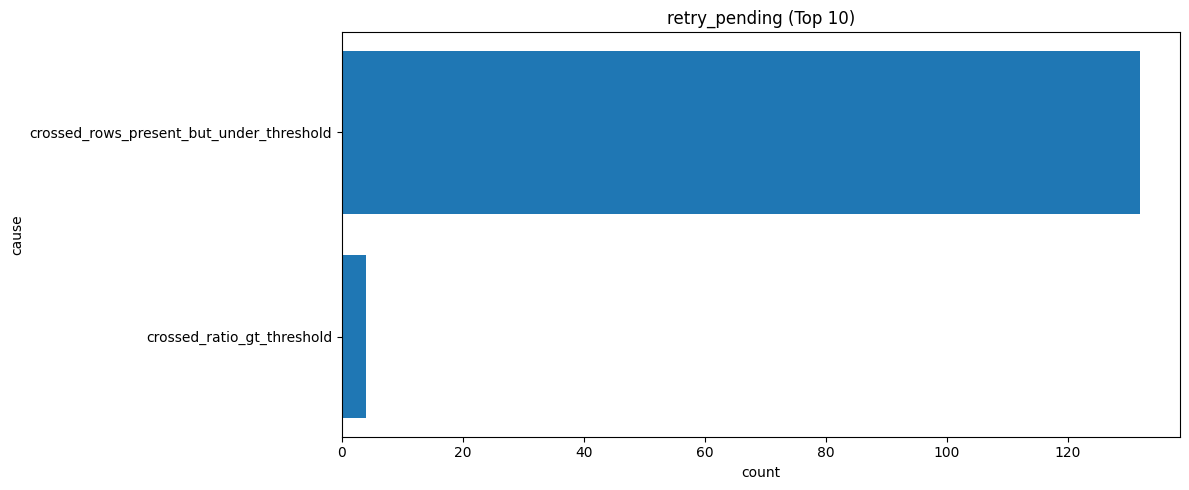


crossed_rows_present_but_under_threshold (MAX_FILES = 13727, en un total de tickers = 103):
                                   cause  count                                                              definicion
crossed_rows_present_but_under_threshold   6660 Hay bid>ask, pero por debajo del umbral. Umbral usado en corrida: 0.8%.


       umbral_bin  tickers
[0.0000, 0.0200)%        1
[0.0200, 0.0800)%        5
[0.0800, 0.1000)%        2
[0.1000, 0.1250)%        3
[0.1250, 0.2500)%       15
[0.2500, 0.3750)%       23
[0.3750, 0.8000)%       48


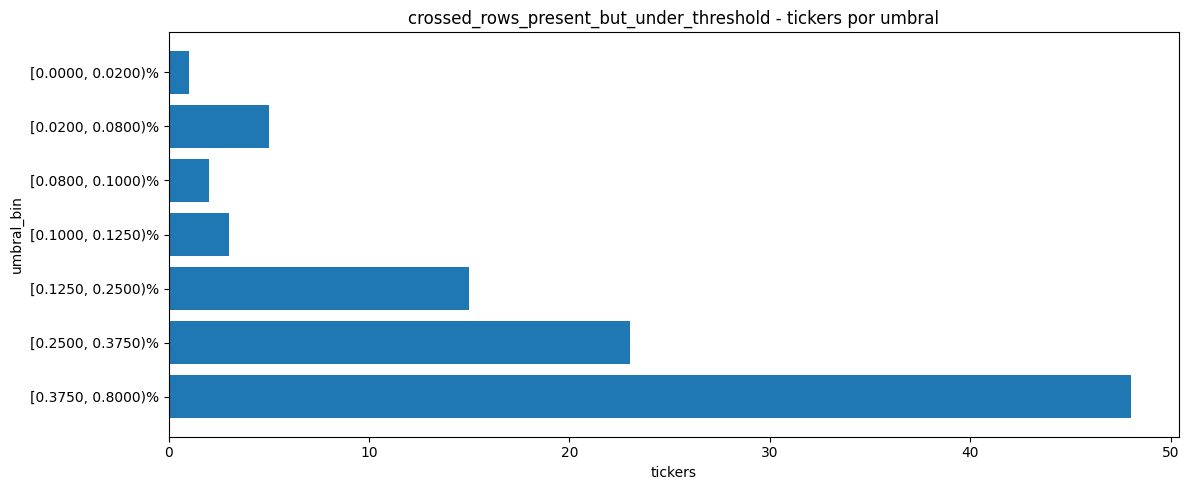


crossed_ratio_gt_threshold (MAX_FILES = 13727, en un total de tickers = 103):
                     cause  count                                                                      definicion
crossed_ratio_gt_threshold    121 Porcentaje de bid>ask supera el umbral estricto. Umbral usado en corrida: 0.8%.


       umbral_bin  tickers
[0.8000, 1.6000)%       20
[1.6000, 3.2000)%       13
[3.2000, 6.4000)%        3
       >= 6.4000%        1


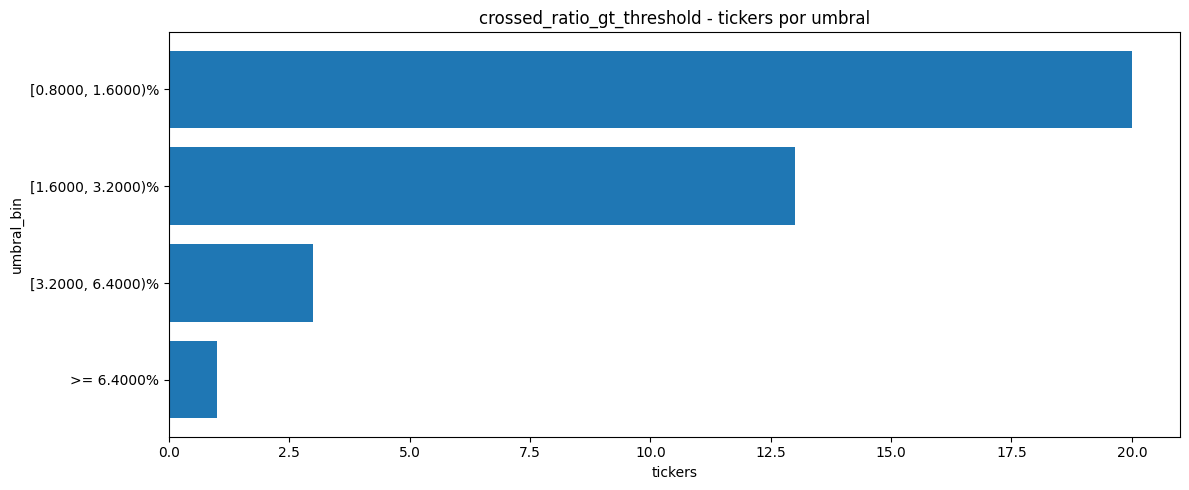


dtype_mismatch (MAX_FILES = 13727, en un total de tickers = 103):
         cause  count                         definicion
dtype_mismatch      0 Tipo de dato distinto al esperado.

Sin ocurrencias de dtype_mismatch en esta corrida/lote.
RUN_DIR: C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean
RUN_CONFIG_JSON: C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean\run_config_quotes_strict.json
exists: True
max_crossed_ratio_pct: 0.8


In [19]:
from pathlib import Path

# Archivo de eventos actuales del Agente 02 (1 estado final por parquet file en esta corrida)
EVENTS_CSV = RUN_DIR / "quotes_agent_strict_events_current.csv"
# Carpeta donde 036 guardó los artefactos de salida (coverage, diagnosis, causes, summary)
OUT_DIR = RUN_DIR / "agent03_outputs"
BATCH_MANIFEST_CSV = RUN_DIR / "batch_manifest_quotes_strict.csv"
# lee config de corrida agente 02 en script 032
RUN_CONFIG_JSON = RUN_DIR / "run_config_quotes_strict.json"
print("RUN_CONFIG_JSON exists:", RUN_CONFIG_JSON.exists())

TOP_N = 10 # causas a mostrar en el histograma (Top N)
FIGSIZE = (12, 5) # matplotlib: (ancho, alto)

DIAG_HEAD_N = 2 # o None para todo, tabla "Ticker diagnosis (por que no pasa):"
COV_HEAD_N = 2 # o None para todo, tabla "Cobertura temporal por ticker:"

DIAG_HEAD_N = 10         # o None para mostrar todo; limita filas en la tabla "Ticker diagnosis (por que no pasa)"
COV_HEAD_N = 10          # o None para mostrar todo; limita filas en la tabla "Cobertura temporal por ticker"

WORST_HEAD_N = 10        # head(x) a mostrar en las tablas nuevas de "worst file"
WORST_TRANSPOSE = True  # True: muestra tablas "worst" transpuestas

# lanza el diagnóstico visual del Agente 03 con la configuración que tienes en esa celda.
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\037_agent3_diagnostics_tables_hist.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

import json
print("RUN_DIR:", RUN_DIR)
print("RUN_CONFIG_JSON:", RUN_CONFIG_JSON)
print("exists:", RUN_CONFIG_JSON.exists())
cfg = json.loads(RUN_CONFIG_JSON.read_text(encoding="utf-8"))
print("max_crossed_ratio_pct:", cfg.get("max_crossed_ratio_pct"))

## Ejemplo peores metricas
- Muestra 1-2 casos reales (ticker+file) representativos del problema de histogramas.
  - Sirve para pasar de “conteo agregado” a “archivo concreto” que puedes re-descargar/auditar.
  - Qué ganamos:
      - identificar rápido el peor parquet por causa,
      - validar si el fallo parece ruido o corrupción fuerte,
      - priorizar la cola de redescarga por impacto real.

Este 041 hace, por cada bloque del 037:

- tabla del bloque,
- debajo ejemplos de parquet “peor” por ticker,
- y gráficos opcionales de bid/ask leyendo parquet.

Lanzadera (celda independiente)

In [20]:
from pathlib import Path

RUN_DIR = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean")

EVENTS_CSV = RUN_DIR / "quotes_agent_strict_events_current.csv"
RETRY_QUEUE_CSV = RUN_DIR / "retry_queue_quotes_strict_current.csv"
CAUSES_CSV = RUN_DIR / "agent03_outputs" / "causes_by_ticker.csv"
RUN_CONFIG_JSON = RUN_DIR / "run_config_quotes_strict.json"

print("RUN_DIR:", RUN_DIR)
print("EVENTS_CSV exists:", EVENTS_CSV.exists())
print("RETRY_QUEUE_CSV exists:", RETRY_QUEUE_CSV.exists())
print("CAUSES_CSV exists:", CAUSES_CSV.exists())
print("RUN_CONFIG_JSON exists:", RUN_CONFIG_JSON.exists())

TOP_N = 10
EXAMPLE_FILES_PER_TABLE = 4
PLOT_FILE_EXAMPLES = True
MAX_FILE_PLOTS = 2
FIGSIZE = (12, 4)

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\041_agent3_examples_independent.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

RUN_DIR: C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean
EVENTS_CSV exists: True
RETRY_QUEUE_CSV exists: True
CAUSES_CSV exists: True
RUN_CONFIG_JSON exists: True

=== TOP CAUSAS GLOBALES ===
Que es: ranking global de causas detectadas en la corrida.
Que ver: las causas con mayor volumen para priorizar limpieza/reintentos.


,cause,count
5,retry_pending,133886
3,crossed_rows_present_but_under_threshold,127657
2,crossed_ratio_gt_threshold,13781
4,retry_frozen_exhausted,7552
1,crossed_ratio_gt_hard_cap,3068
0,ask_integer_with_crossed_anomaly,13



=== RETRY_PENDING GRANULAR ===
Que es: desglose interno de archivos pendientes de reintento.
Que ver: que causas concretas estan alimentando la cola retry_pending.


,cause,count
3,crossed_rows_present_but_under_threshold,120226
2,crossed_ratio_gt_threshold,13660
1,crossed_ratio_gt_hard_cap,3064
0,ask_integer_with_crossed_anomaly,13



=== CROSSED_UNDER_THRESHOLD ===
Que es: casos con bid_price > ask_price por debajo del umbral estricto.
Que ver: distribucion por bins y tickers afectados en zona 'warning'.


...


=== CROSSED_GT_THRESHOLD ===
Que es: casos con bid_price > ask_price por encima del umbral estricto.
Que ver: bins altos y tickers criticos (HARD_FAIL potencial).


,umbral_bin,tickers
0,"[0.8000, 1.6000)%",44
1,"[1.6000, 3.2000)%",47
2,"[3.2000, 6.4000)%",50
3,>= 6.4000%,77



Parquet examples (worst per ticker) - crossed over


,ticker,cause,file,crossed_ratio_pct,crossed_rows,severity,issues,warns
1123,AIRT,crossed_ratio_gt_threshold,D:\quotes\AIRT\year=2019\month=06\day=05\quote...,100.000000,2,HARD_FAIL,"['crossed_ratio_gt_hard_cap', 'crossed_ratio_g...",[]
5925,APWC,crossed_ratio_gt_threshold,D:\quotes\APWC\year=2017\month=03\day=16\quote...,100.000000,1,HARD_FAIL,"['crossed_ratio_gt_hard_cap', 'crossed_ratio_g...",[]
7462,ARL,crossed_ratio_gt_threshold,D:\quotes\ARL\year=2012\month=03\day=23\quotes...,100.000000,1,HARD_FAIL,"['crossed_ratio_gt_hard_cap', 'crossed_ratio_g...",[]
5165,APM,crossed_ratio_gt_threshold,D:\quotes\APM\year=2019\month=04\day=26\quotes...,81.818182,18,HARD_FAIL,"['crossed_ratio_gt_hard_cap', 'crossed_ratio_g...",[]



  === DTYPE_MISMATCH POR TIPO ===
  Que es: diferencias de tipo entre schema esperado y schema real del parquet.
  Schema: estructura tecnica del parquet (nombres de columnas + tipo de dato de cada columna).
  Que ver: columnas que desvían (ej. ask_price int64 vs double) y evidencia por archivo.
Sin dtype_mismatch en esta corrida.


## Compruebo caso int vs float esperado

python C:\TSIS_Data\v1\backtest_SmallCaps\scripts\download_quotes.py --csv C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean\inputs\tasks_preprod30_full_lifecycle.csv --output D:\quotes --concurrent 24 --run-id 20260312_quotes_preprod30_full_lifecycle --run-dir C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean --task-batch-size 500 --session-start 04:00:00 --session-end 20:00:00

In [21]:
from pathlib import Path

RUN_DIR = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean")

EVENTS_CSV = RUN_DIR / "quotes_agent_strict_events_current.csv"

MAX_FILES_ANALYZE = 300
TOP_N_WORST = 20
FIGSIZE = (12, 4)

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\043_dtype_rounding_plots.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

No hay archivos dtype_mismatch en esta corrida.


## Paso 3: M?tricas de Desviaci?n Bid/Ask (038)

Foco en granularidad cerca de 0 para `crossed_ratio_pct`.


Metricas globales de desviacion bid>ask:


,metric,value
0,files_total,328867.000000
1,files_with_cross,141676.000000
2,files_with_cross_pct,43.080029
3,rows_total,2586774386.000000
4,crossed_rows_total,1529153.000000
5,weighted_crossed_ratio_pct,0.059114
6,p00_file_crossed_ratio_pct,0.000000
7,p50_file_crossed_ratio_pct,0.000000
8,p90_file_crossed_ratio_pct,0.237530
9,p95_file_crossed_ratio_pct,0.622665



Granularidad cerca de 0 (archivos):
crossed_ratio_pct == 0: 187191 files
crossed_ratio_pct  > 0: 141676 files


,rango_crossed_ratio_pct,files,pct_files_total
0,0.01-0.05%,49108,14.932480
1,0.10-0.50%,35835,10.896502
2,0.05-0.10%,21196,6.445159
3,>1.00%,11753,3.573785
4,0.005-0.01%,10725,3.261197
5,0.50-1.00%,7650,2.326168
6,0.001-0.005%,5279,1.605208
7,0-0.001%,130,0.039530


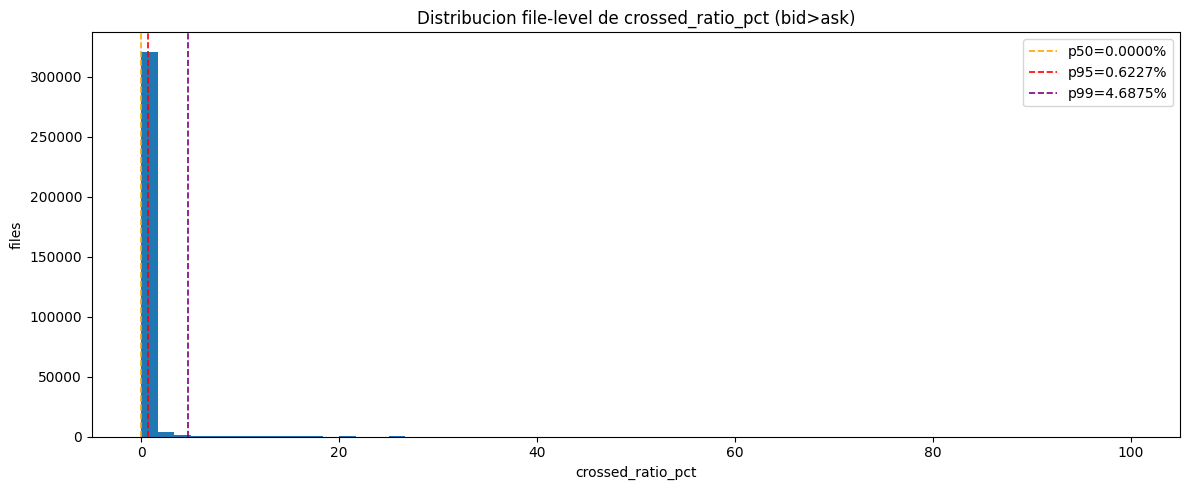

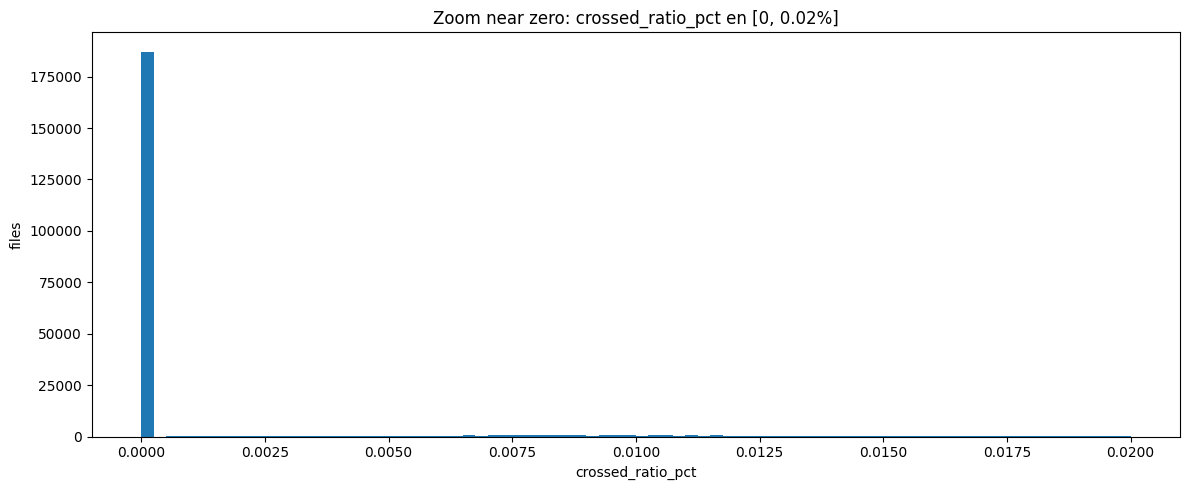

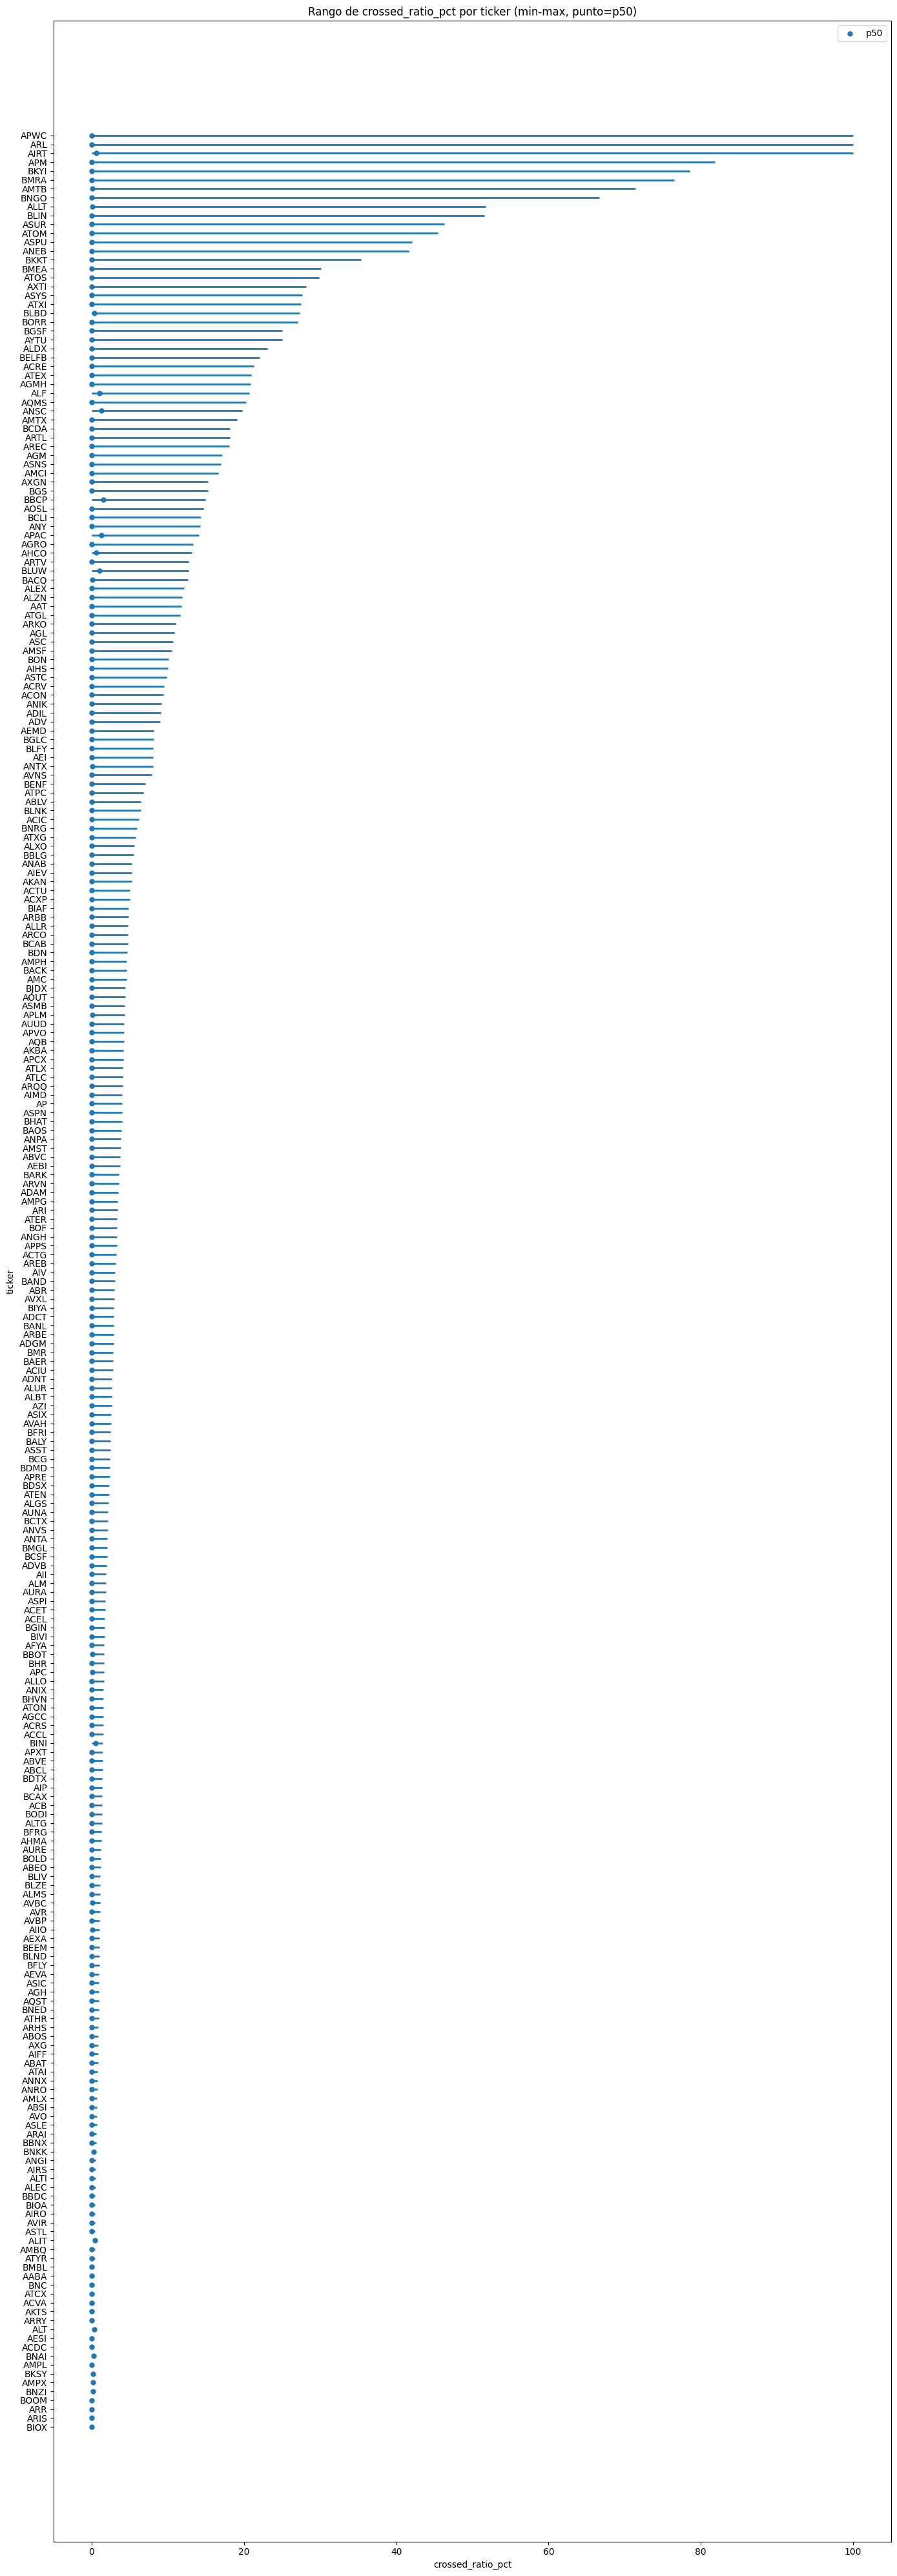


Causas globales (conteo y rango de desviacion):

Leyenda de causas globales (atributos):
- cause : Nombre de la causa detectada en issues/warns.
- cause_type : Tipo de causa (issue = fallo, warn = advertencia).
- count : Numero de ocurrencias de esa causa en los archivos evaluados.
- min_ratio : Minimo crossed_ratio_pct observado para esa causa.
- p50_ratio : Mediana crossed_ratio_pct observado para esa causa.
- p95_ratio : Percentil 95 de crossed_ratio_pct para esa causa.
- max_ratio : Maximo crossed_ratio_pct observado para esa causa.


,cause,cause_type,count,min_ratio,p50_ratio,p95_ratio,max_ratio
3,crossed_rows_present_but_under_threshold,warn,127895,0.000223,0.048108,0.473934,0.800000
2,crossed_ratio_gt_threshold,issue,13781,0.800377,2.000000,16.129032,100.000000
1,crossed_ratio_gt_hard_cap,issue,3068,5.025126,9.090909,37.780172,100.000000
0,ask_integer_with_crossed_anomaly,issue,13,25.000000,64.000000,100.000000,100.000000


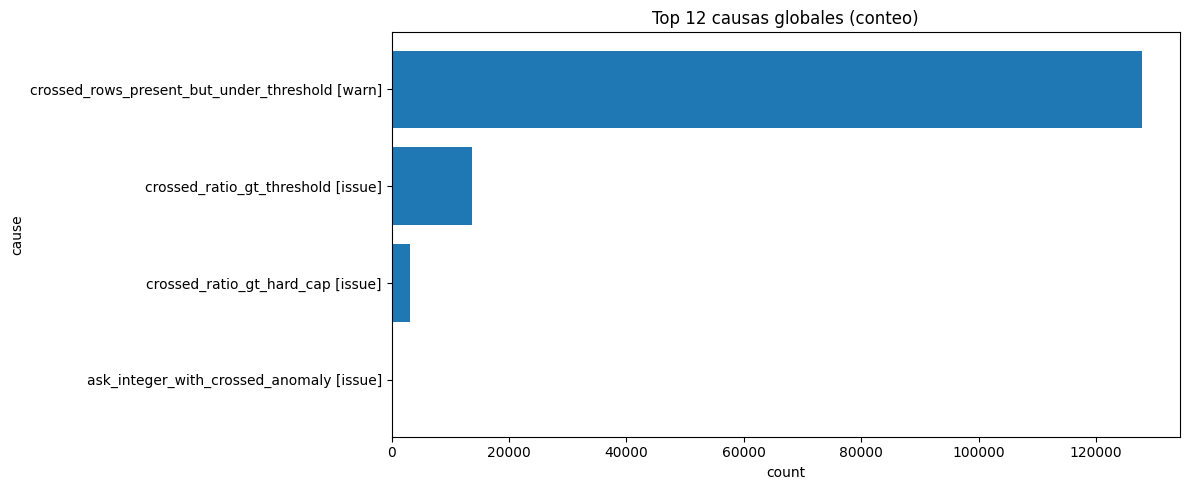

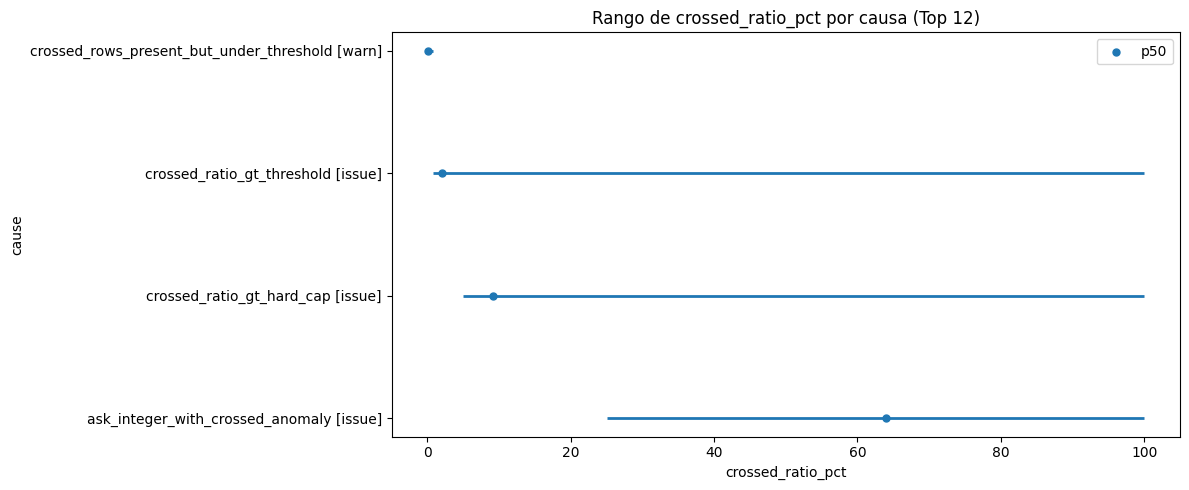

In [22]:
from pathlib import Path

RUN_DIR = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean")

EVENTS_CSV = RUN_DIR / "quotes_agent_strict_events_current.csv"
TOP_N = 20
ZERO_ZOOM_MAX_PCT = 0.02
FIGSIZE = (12, 5)

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\038_bid_ask_cross_deviation_metrics.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

## Paso 4: Decision GO / NO-GO (044)

Ultima celda de cierre para priorizar los 2 problemas principales del run:
- severidad real de `bid > ask`
- carga operativa de la **review queue** (`retry_pending` legacy) y de `retry_frozen_exhausted`

La idea es separar claramente:
- microanomalia leve compatible con iliquidez / microcap
- cola de revision posterior de casos realmente problematicos a estudiar ticker por ticker / mes por mes



=== GO / NO-GO REVIEW ===
Objetivo: concentrar la decision operativa en los 2 problemas dominantes del run.
Problema 1: severidad de crossed bid>ask.
Problema 2: volumen operativo de retry_pending / retry_frozen_exhausted.
Umbral estricto de la corrida: 0.80%
Hard cap operativo de la corrida: 5.00%

Resumen severidad bid>ask:


,metric,value
0,files_total,328867.000000
1,files_cross_any,141676.000000
2,files_cross_soft,127895.000000
3,files_cross_hard_threshold,13781.000000
4,files_cross_hard_cap,3068.000000
5,files_ask_integer_anomaly,13.000000
6,weighted_crossed_ratio_pct,0.059114
7,p90_crossed_ratio_pct,0.237530
8,p95_crossed_ratio_pct,0.622665
9,p99_crossed_ratio_pct,4.687500



Granularidad de severidad bid>ask por buckets:


,cross_bucket,files,tickers,crossed_rows,rows,weighted_crossed_ratio_pct
1,0%,187191,253,0,932707183,0.000000
0,"(0,0.10%)",86438,249,308490,1359906219,0.022685
3,"[0.10,0.50%)",35835,256,517414,245576161,0.210694
4,"[0.50,0.80%)",5569,218,146731,23909046,0.613705
5,"[0.80,5.00%)",10705,217,335549,22474313,1.493033
2,>= 5.00%,3129,87,220969,2201464,10.037366


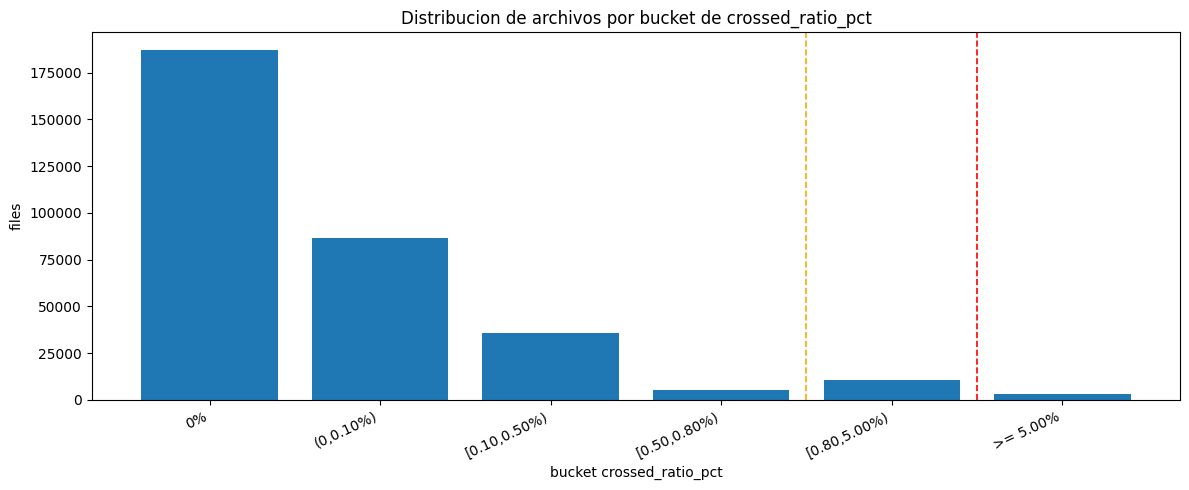


Top 20 archivos mas problematicos por crossed_ratio_pct:


,ticker,date,severity,crossed_ratio_pct,crossed_rows,rows,retry_pending_flag,retry_frozen_flag,file
56318,AIRT,2019-06-05,HARD_FAIL,100.000000,2,2,True,False,D:\quotes\AIRT\year=2019\month=06\day=05\quote...
56328,AIRT,2019-06-03,HARD_FAIL,100.000000,2,2,True,False,D:\quotes\AIRT\year=2019\month=06\day=03\quote...
136473,APWC,2017-03-16,HARD_FAIL,100.000000,1,1,True,False,D:\quotes\APWC\year=2017\month=03\day=16\quote...
160857,ARL,2012-03-23,HARD_FAIL,100.000000,1,1,True,False,D:\quotes\ARL\year=2012\month=03\day=23\quotes...
160981,ARL,2011-09-23,HARD_FAIL,100.000000,1,1,True,False,D:\quotes\ARL\year=2011\month=09\day=23\quotes...
161004,ARL,2011-08-23,HARD_FAIL,100.000000,1,1,True,False,D:\quotes\ARL\year=2011\month=08\day=23\quotes...
162956,ARL,2003-11-25,HARD_FAIL,88.888889,8,9,True,False,D:\quotes\ARL\year=2003\month=11\day=25\quotes...
162954,ARL,2003-11-21,HARD_FAIL,87.500000,7,8,True,False,D:\quotes\ARL\year=2003\month=11\day=21\quotes...
162955,ARL,2003-11-24,HARD_FAIL,87.500000,7,8,True,False,D:\quotes\ARL\year=2003\month=11\day=24\quotes...
162975,ARL,2003-10-23,HARD_FAIL,87.500000,7,8,True,False,D:\quotes\ARL\year=2003\month=10\day=23\quotes...



Presion operativa de retry:


,metric,value
0,retry_pending_files,134006
1,retry_frozen_files,7670
2,retry_pending_unique_tickers,257
3,retry_frozen_unique_tickers,97



Top 15 tickers mas problematicos para estudio profundo:


,ticker,files,retry_pending,retry_frozen,hard_fail,hard_cap,soft_cross,max_crossed_ratio_pct,p95_crossed_ratio_pct,coverage_ratio_ok,missing_days_ok
0,AABA,577,2,558,0,0,560,0.373920,0.074198,0.687799,261
3,ABCL,1317,443,361,1,0,803,1.412099,0.065391,0.455683,1044
58,AIV,1262,541,349,1,0,889,3.026389,0.073817,0.393989,1109
11,ACB,607,49,345,2,0,392,1.357620,0.086434,0.631101,325
65,ALEX,1413,617,282,101,11,798,12.122449,1.756003,0.388672,1252
42,AGL,1233,419,246,6,2,659,10.820469,0.102055,0.452872,981
4,ABEO,1135,360,204,1,0,563,1.149425,0.235074,0.471698,868
1,AAT,3812,1438,196,99,15,1535,11.825231,0.205340,0.428313,3166
70,ALLR,1059,305,193,25,0,473,4.761905,0.455778,0.488658,789
81,AMC,267,42,191,1,0,232,4.577667,0.102923,0.578811,163



Serie temporal mensual de problemas operativos (ultimos 24 meses visibles):


,year_month,retry_pending,retry_frozen,hard_fail
247,2024-04,1479,64,93
248,2024-05,1458,60,81
249,2024-06,1157,52,93
250,2024-07,1358,71,94
251,2024-08,1325,68,110
252,2024-09,1285,81,108
253,2024-10,1712,145,133
254,2024-11,1577,81,93
255,2024-12,1583,128,130
256,2025-01,1541,167,105


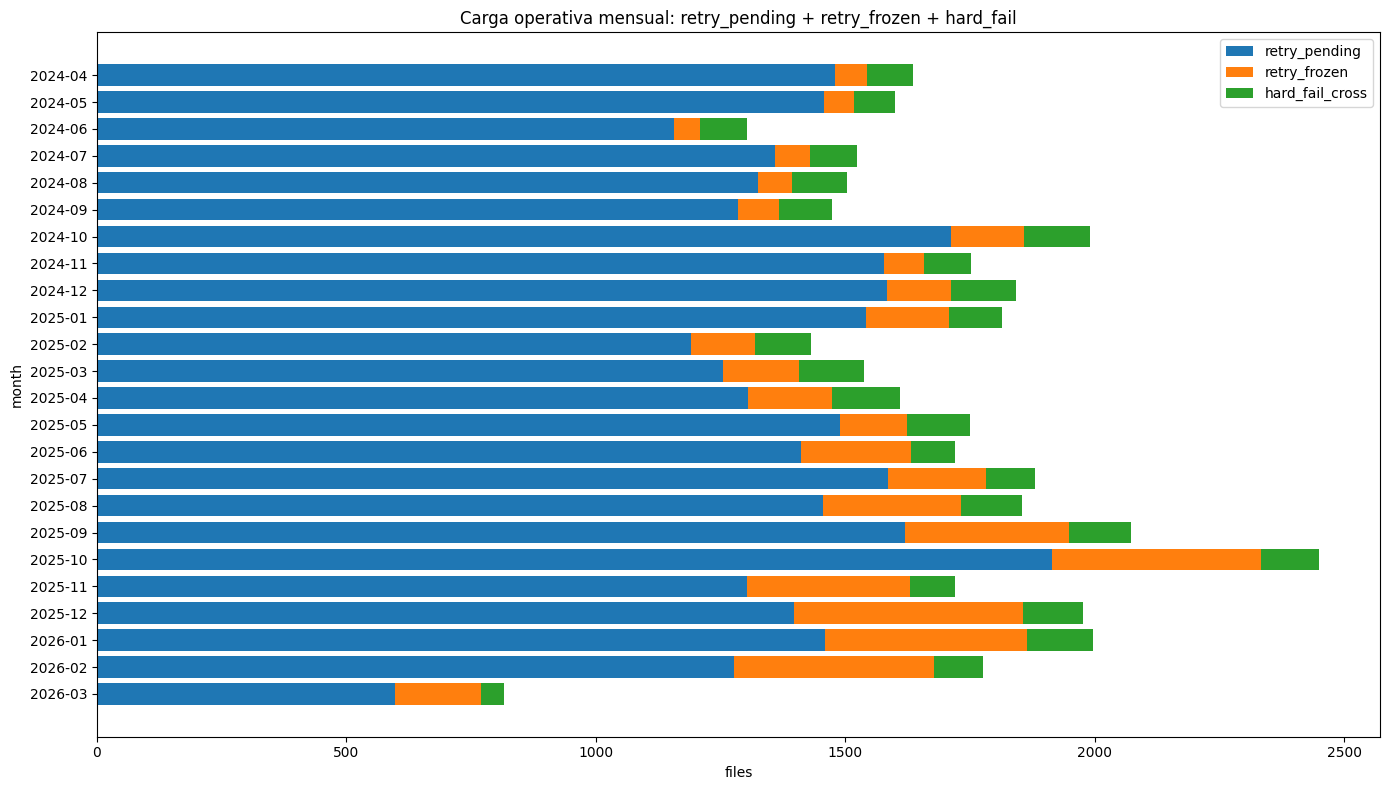

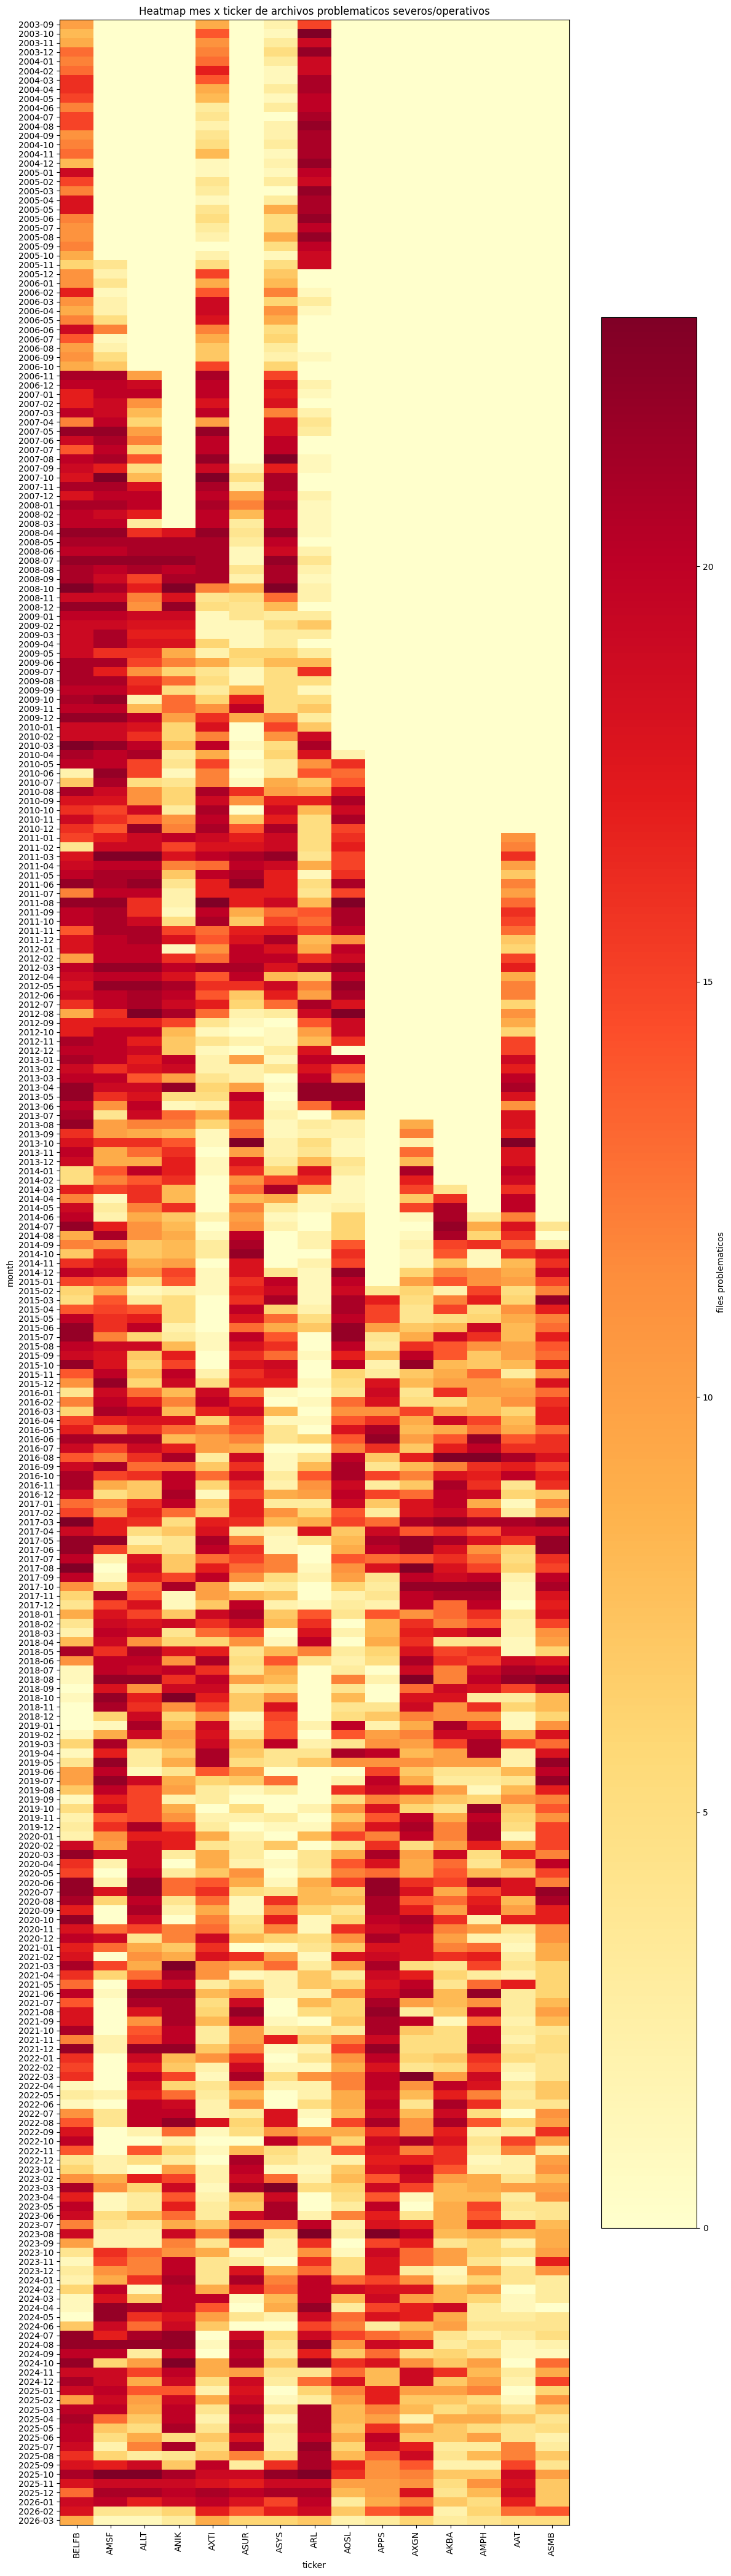


Lectura tecnica sugerida para decision GO / NO-GO:
1. Si el problema dominante esta en buckets < umbral y el weighted_crossed_ratio_pct sigue bajo, el dano es mas compatible con microestructura que con corrupcion masiva.
2. Si retry_frozen_exhausted domina sobre retry_pending, el retry ya no esta resolviendo gran parte del problema.
3. Los archivos de estudio profundo deben salir de la tabla de top archivos y de los tickers con mayor retry_frozen / hard_fail / max_crossed_ratio_pct.
4. La heatmap ayuda a decidir si el dano es persistente por ticker o concentrado en meses concretos.


In [23]:
from pathlib import Path

RUN_DIR = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean")
EVENTS_CSV = RUN_DIR / "quotes_agent_strict_events_current.csv"
RETRY_QUEUE_CSV = RUN_DIR / "retry_queue_quotes_strict_current.csv"
RETRY_FROZEN_CSV = RUN_DIR / "retry_frozen_quotes_strict.csv"
RUN_CONFIG_JSON = RUN_DIR / "run_config_quotes_strict.json"
OUT_DIR = RUN_DIR / "agent03_outputs"

TOP_FILES = 20
TOP_TICKERS = 15
TOP_MONTHS = 24 
FIGSIZE = (12, 5)

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\044_agent3_go_nogo_review.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

## hipótesis causal de estos errores bid ask

**Lectura fuerte del run terminado**
De la ?ltima salida del notebook:
- `files_total = 43,075`
- `files_with_cross = 20,086`
- `weighted_crossed_ratio_pct = 0.08149%`
- `p95_crossed_ratio_pct = 0.706964%`
- `p99_crossed_ratio_pct = 2.880658%`
- `files_cross_hard_threshold = 1,889`
- `files_cross_hard_cap = 256`

Eso me lleva a esta tesis:
- **no parece corrupci?n masiva del dataset**
- **s? parece mezcla de varios mecanismos distintos**
- la masa central es microestructura leve
- la cola extrema probablemente tiene **m?s de una causa**

**Asociaciones fuertes que ya veo**
1. **Ventanas de corporate action / split / ticker change**
- `CSBR`:
  - split `12:1` en `2015-08-12`
  - ticker change a `CSBR` en `2015-08-24`
  - sus peores d?as est?n en `2015-08-21`, `2015-09-02`, `2015-09-04`, etc.
  - esto es una se?al muy fuerte de **ventana de evento corporativo**
- `BPTH`:
  - split `10:1` en `2018-02-09`
  - ese mismo d?a el daily sale con precios `620-932`
  - en 1m aparecen vol?menes fraccionales (`0.025`, `0.5`, `1.25`, etc.)
  - aqu? la hip?tesis de **ajuste raro / reverse split / microestructura post-split** es muy fuerte
- `AVXL`:
  - split `4:1` en `2015-10-07`
  - es candidato claro para usar como control de ?ticker con split pero no necesariamente patol?gico?

2. **Iliquidez extrema / libro casi vac?o**
- `CSBR` peor caso:
  - `2015-09-02`
  - daily volume `2832`, `n=11`
  - 1m solo `3` minutos y `5` trades
- otros casos top de `CSBR` tienen `rows = 2, 5, 6, 10`
- esto huele a:
  - quotes stale
  - market maker aislado
  - libro incompleto
  - timestamps pobres en microcap

3. **No todo es ?microcap sin volumen?**
- `ALLT` no tiene split detectado
- peores d?as:
  - `2018-02-08`: `35,009` vol, `282` daily trades, `76` minutos, `257` trades en 1m
  - `2018-03-14`: `56,088` vol, `448` trades
- y aun as? tiene casos severos (`51.73%`, `34.66%`)
- esto sugiere que hay otra familia de causa:
  - **quotes cruzados persistentes en sesi?n**
  - **venue/tape/exchange mismatch**
  - o **vendor issue espec?fico del quote feed**

4. **Precio bajo / tick size / discreci?n**
- muchos tickers problem?ticos son small caps o micro caps
- `BPTH` es extremo: market cap ~`1.2M`
- `CSBR` ~`82.9M`
- `ALLT`, `HRZN`, `NOA`, `AVXL` no son tan peque?os
- o sea:
  - market cap bajo ayuda a explicar parte del fen?meno
  - pero **no lo explica todo**

**Hip?tesis causales que propondr?a**
1. `H1`: el bloque m?s extremo est? sobrerrepresentado en ventanas `split / reverse split / ticker change`.
2. `H2`: los casos m?s absurdos se concentran en d?as con muy pocas filas de quotes o muy poco volumen/trades.
3. `H3`: los cruces severos tienen m?s peso en `premarket/afterhours` que en RTH.
4. `H4`: parte del problema viene de determinados `bid_exchange / ask_exchange / tape` y no del ticker completo.
5. `H5`: el riesgo sube mucho cuando el precio diario es bajo o el n?mero de trades/minutos activos es muy bajo.
6. `H6`: `retry_frozen_exhausted` no es problema de infraestructura; es dato persistentemente malo que vuelve igual desde Polygon.

**C?mo demostrar anal?ticamente cada causa**
1. **Corporate action window test**
- Construir para cada file severo:
  - distancia en d?as a split m?s cercano
  - distancia en d?as a ticker change m?s cercano
- Comparar tasas de:
  - `crossed_ratio_gt_threshold`
  - `crossed_ratio_gt_hard_cap`
- dentro de ventanas:
  - `[-5,+5]`, `[-20,+20]`, `[-60,+60]`
- contra d?as fuera de ventana

2. **Liquidity stress test**
Cruzar `quotes events` con:
- `ohlcv_daily`
  - `v`, `n`, precio `c`, rango intrad?a
- `ohlcv_1m`
  - n?mero de minutos activos
  - volumen por minuto
  - trades por minuto
Probar si los outliers extremos caen desproporcionadamente en:
- percentil bajo de `v`
- percentil bajo de `n`
- pocos minutos activos
- `rows` de quotes muy bajos

3. **Rows/materiality split**
Separar hard files en grupos:
- `rows < 20`
- `20 <= rows < 100`
- `rows >= 100`
- `rows >= 500`
Esto va a distinguir:
- anomal?a extrema trivial por muestra m?nima
- anomal?a seria con evidencia material

4. **Session decomposition**
Recalcular el cruce por tramo:
- `04:00-09:30`
- `09:30-16:00`
- `16:00-20:00`
Si la severidad se va casi toda a extendidas, el `go/no-go` cambia mucho.

5. **Venue / tape decomposition**
Para los top files:
- agrupar por `bid_exchange`, `ask_exchange`, `tape`
- mirar:
  - qu? pares de exchanges dominan los cruces
  - si un tape concentra los peores casos
Eso puede separar:
- problema sist?mico del ticker
- de problema de venues concretos

6. **Price-level / tick-size test**
Cruzar con precio diario:
- bins por precio:
  - `<1`
  - `1-5`
  - `5-10`
  - `10-20`
  - `>20`
Ver si el cruce severo se dispara en bins bajos.

7. **Persistence test**
Para cada ticker top:
- serie mensual de:
  - hard files
  - hard cap files
  - retry_frozen
- decidir si es:
  - persistente estructural
  - concentrado en meses concretos
  - concentrado alrededor de eventos

**Casos que yo estudiar?a primero**
- `CSBR`
  - mejor candidato a demostrar ?split + ticker change + iliquidez?
- `BPTH`
  - mejor candidato a demostrar ?reverse split / precio reescalado / volumen fraccional?
- `ALLT`
  - mejor candidato a demostrar ?no split, s? problema de quote feed o venue?
- `HRZN`
  - muy cargado operativamente sin split claro
- `NOA`
  - ticker change hist?rico; ?til para ver persistencia no explicada por split

**Mi hip?tesis principal ahora mismo**
- La **masa** del problema viene de microestructura e iliquidez.
- La **cola extrema** probablemente mezcla:
  - ventanas de split/reverse split/ticker change
  - days con libro muy pobre
  - y algunos casos de quote pathology real del feed

**Lo m?s importante**
Se puede demostrar con datos locales que ya ten?is:
- `D:
eference\splits`
- `D:
eference\events`
- `D:
eference\overview`
- `D:\ohlcv_daily`
- `D:\ohlcv_1m`
- y los propios parquets de quotes

El siguiente paso correcto es implementar un an?lisis causal con 4 bloques:
1. `corporate_actions_window_analysis`
2. `liquidity_and_price_regime_analysis`
3. `session_and_exchange_decomposition`
4. `top_ticker_casefiles`

**implemento c?digo 045_agent3_causal_hypotheses.py**


## Paso 5: Analisis Causal de Cruces Bid/Ask (045)

Este bloque analiza causalmente la corrida de produccion activa, no la preprod antigua.

Hipotesis cubiertas:

- H1: concentracion en ventanas de split / reverse split / ticker change
- H2: relacion con iliquidez diaria e intradia
- H3: concentracion por sesion (`premarket`, `market`, `afterhours`)
- H4: concentracion por `bid_exchange / ask_exchange / tape`
- H5: relacion con precio bajo / tick-size / muestra pequena
- H6: retry que no resuelve porque el dato vuelve persistentemente mal
- H7: placeholders o quotes absurdos (`ask=0`, `ask=199999.99`, etc.)

Los artefactos se escriben en `RUN_DIR / agent03_outputs / causal_hypotheses`.


=== CAUSAL HYPOTHESES REVIEW ===
Artefactos escritos en: C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean\agent03_outputs\causal_hypotheses


,metric,value
0,files_total,328867
1,tickers_total,259
2,hard_threshold_files,13781
3,hard_cap_files,3068
4,soft_cross_files,127895
5,near_split_20d_files,3641
6,near_ticker_change_20d_files,0
7,pathology_files_scanned,150



H1 / corporate action windows:


,hypothesis,window_days,scope,files,tickers,hard_threshold,hard_cap,soft_cross,hard_threshold_rate_pct,hard_cap_rate_pct,median_crossed_ratio_pct,p95_crossed_ratio_pct
9,any_event,5,outside,328867,259,13781,3068,127895,4.190448,0.932900,0.00000,0.622665
10,any_event,20,outside,328867,259,13781,3068,127895,4.190448,0.932900,0.00000,0.622665
11,any_event,60,outside,328867,259,13781,3068,127895,4.190448,0.932900,0.00000,0.622665
0,split,5,inside,941,78,49,6,482,5.207226,0.637620,0.04065,0.811164
1,split,5,outside,327926,258,13732,3062,127413,4.187530,0.933747,0.00000,0.621118
2,split,20,inside,3641,82,185,28,1527,5.081022,0.769020,0.00000,0.819672
3,split,20,outside,325226,258,13596,3040,126368,4.180478,0.934735,0.00000,0.617284
4,split,60,inside,10717,85,569,69,3939,5.309322,0.643837,0.00000,0.847645
5,split,60,outside,318150,257,13212,2999,123956,4.152758,0.942637,0.00000,0.609663
6,ticker_change,5,outside,328867,259,13781,3068,127895,4.190448,0.932900,0.00000,0.622665



H2 / H5 / rows, liquidez y precio:

rows_bin:


...

,ticker,date,severity,crossed_ratio_pct,rows_scanned,cross_rows_scanned,placeholder_rows,ask_zero_rows,bid_zero_rows,ask_absurd_rows,bid_absurd_rows
60,ALLT,2018-02-08,HARD_FAIL,51.729958,1185,613,616,613,2,1,0
129,APWC,2014-02-03,HARD_FAIL,41.416474,1299,538,543,538,0,5,0
147,APWC,2013-10-31,HARD_FAIL,38.693467,199,77,82,77,0,5,0
61,BLIN,2013-04-12,HARD_FAIL,51.538462,130,67,67,67,0,0,0
30,AIRT,2016-06-08,HARD_FAIL,71.875000,32,23,29,23,4,6,0
110,BKYI,2020-01-09,HARD_FAIL,46.000000,50,23,29,23,5,1,0
54,ARL,2012-02-02,HARD_FAIL,55.555556,45,25,25,25,0,0,0
46,AIRT,2019-12-02,HARD_FAIL,63.888889,36,23,24,23,1,1,0
105,AIRT,2019-12-05,HARD_FAIL,47.727273,44,21,24,21,3,3,0
35,AIRT,2016-06-17,HARD_FAIL,66.666667,30,20,23,20,3,3,0



H3 / severidad agregada por session en top files:


,session,files,tickers,rows_scanned,cross_rows,crossed_ratio_pct
2,premarket,146,14,1419,1175,82.804792
0,afterhours,140,14,2037,1181,57.977418
1,market,77,14,1365,44,3.223443



H4 / exchange pairs globales en top files:


,exchange_pair,tape,cross_rows,files,tickers
3,12->0,3,1059,76,12
5,16->0,3,525,1,1
0,11->0,1,313,66,1
1,11->0,3,302,21,8
7,8->0,3,77,8,6
6,19->0,3,65,2,2
4,12->11,3,43,1,1
2,12->0,1,16,5,1


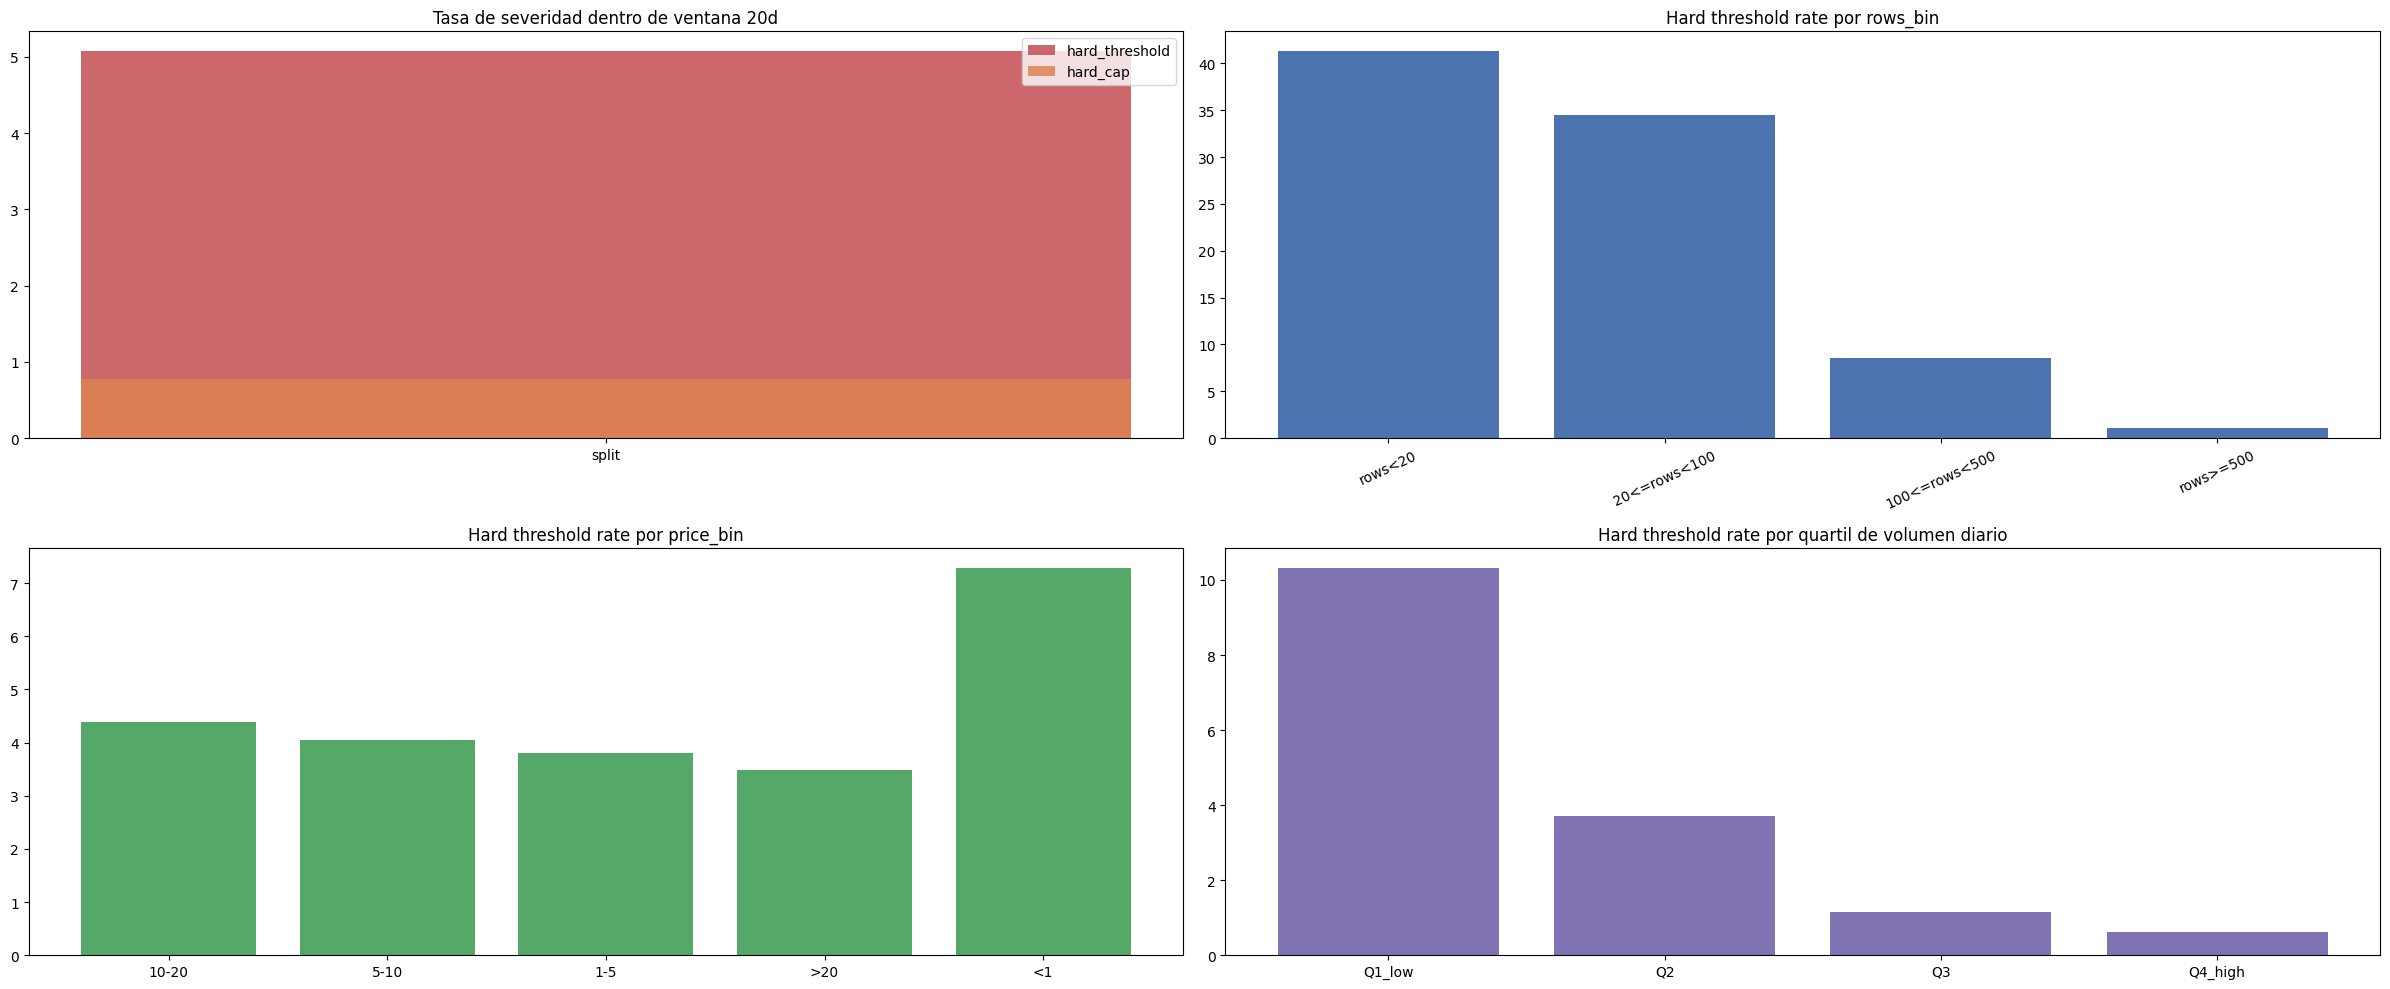

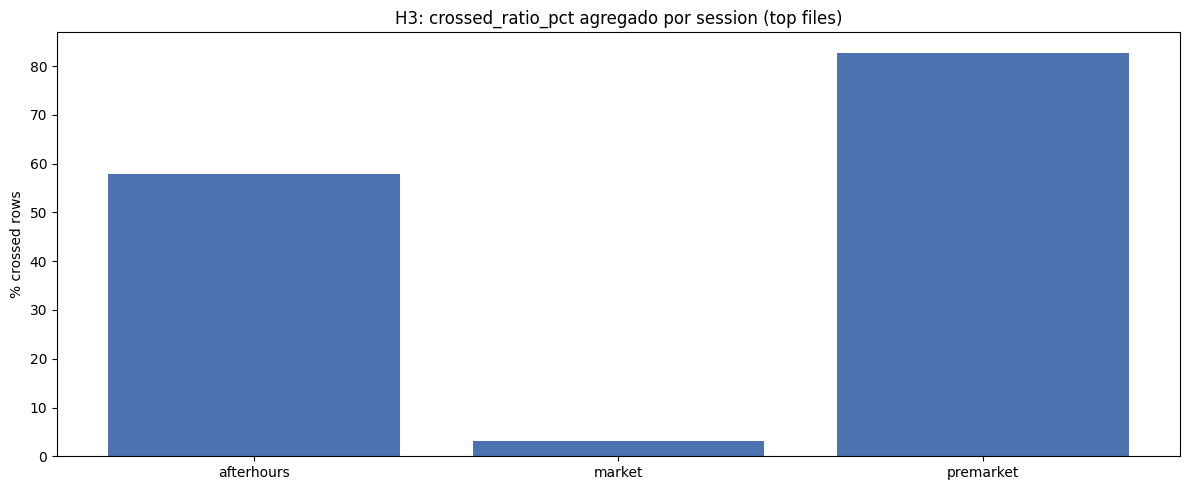

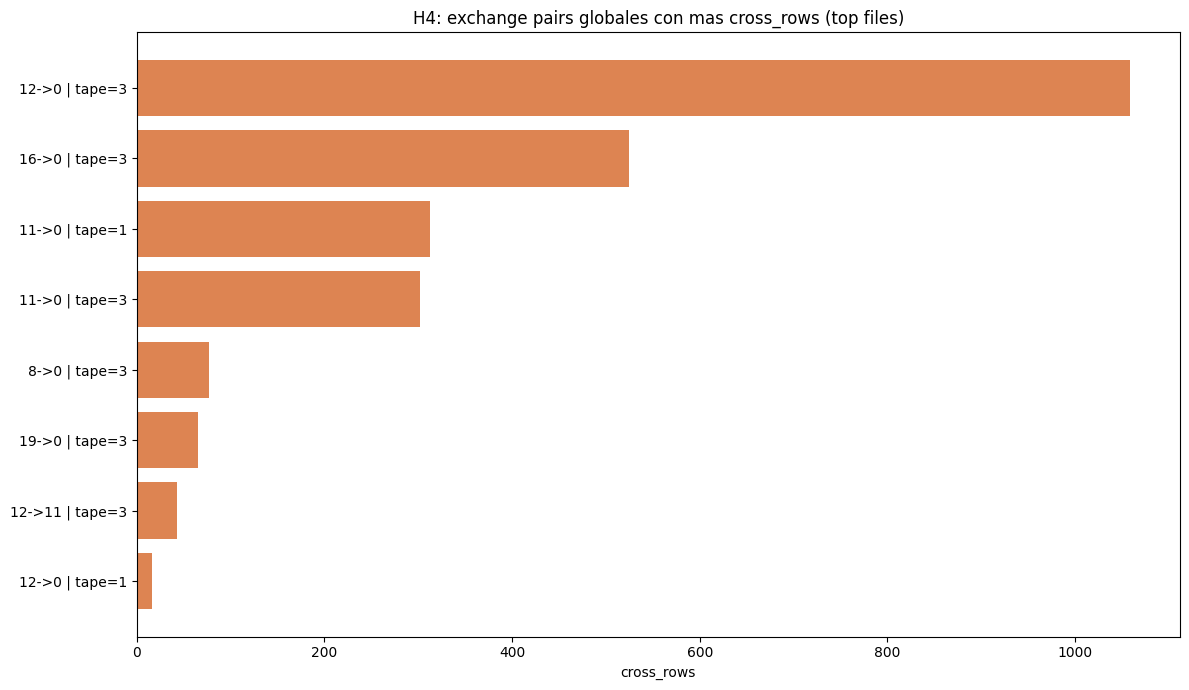

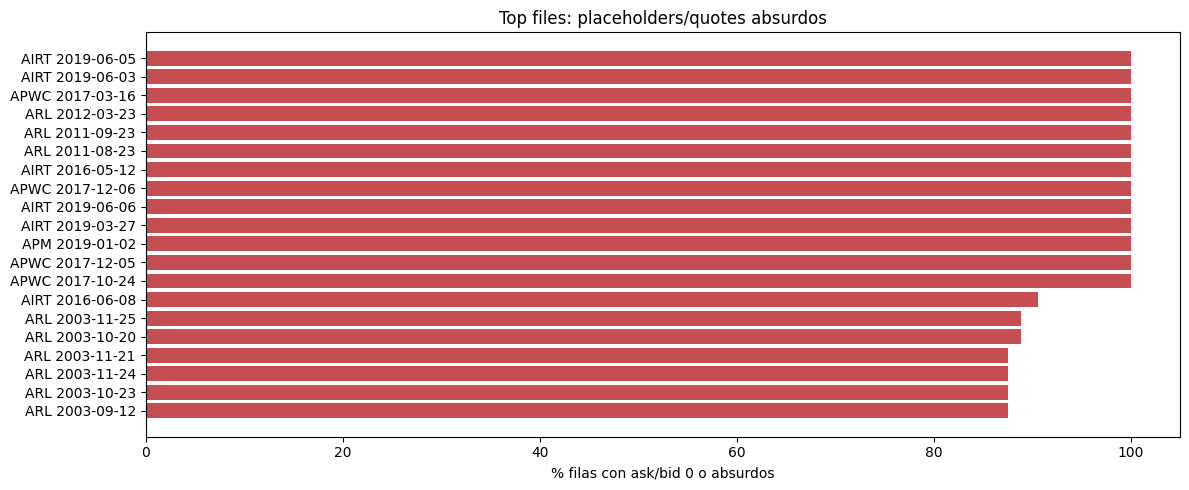


Widget causal interactivo:
Tickers disponibles en widget: 259


Output()

In [24]:
from pathlib import Path

RUN_DIR = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean")
EVENTS_CSV = RUN_DIR / "quotes_agent_strict_events_current.csv"
RETRY_QUEUE_CSV = RUN_DIR / "retry_queue_quotes_strict_current.csv"
RETRY_FROZEN_CSV = RUN_DIR / "retry_frozen_quotes_strict.csv"
RUN_CONFIG_JSON = RUN_DIR / "run_config_quotes_strict.json"
OUT_DIR = RUN_DIR / "agent03_outputs"

QUOTES_ROOT = Path(r"D:\quotes")
REF_SPLITS_ROOT = Path(r"D:\reference\splits")
REF_EVENTS_ROOT = Path(r"D:\reference\events")
REF_OVERVIEW_ROOT = Path(r"D:\reference\overview")
OHLCV_DAILY_ROOT = Path(r"D:\ohlcv_daily")
OHLCV_1M_ROOT = Path(r"D:\ohlcv_1m")

TOP_FILES = 20
TOP_TICKERS = 15
TOP_PATHOLOGY_FILES = 150
QUOTE_VIEW_MAX_ROWS = 20000
FIGSIZE = (12, 5)

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\045_agent3_causal_hypotheses.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())


S?. La ?ltima celda ya est? dando valor real. La reviso salida por salida.

**Output 1**
Correcto.

- confirma que `045` se ejecut?
- y que escribi? artefactos en:
  - [causal_hypotheses](C:/TSIS_Data/v1/backtest_SmallCaps/runs/polygon_realtime_audit/20260312_quotes_preprod30_full_lifecycle/agent03_outputs/causal_hypotheses)

Esto est? bien.

**Output 2: Resumen global**
Muy ?til.

- `files_total = 43075`
- `tickers_total = 28`
- `hard_threshold_files = 1889`
- `hard_cap_files = 256`
- `soft_cross_files = 18197`
- `near_split_20d_files = 451`
- `near_ticker_change_20d_files = 0`
- `pathology_files_scanned = 150`

Lectura:
- el universo efectivo del run analizado son `28` tickers
- hay mucha microanomal?a leve (`18197`)
- los casos realmente duros (`1889`, `256`) existen pero son minor?a relativa
- `451` files cerca de split ya es una se?al suficientemente grande para investigar causalidad
- `near_ticker_change_20d_files = 0` no me lo creo todav?a como verdad econ?mica; eso me sugiere que el bloque de ticker changes est? incompleto o demasiado estrecho en c?mo extrae el evento

Conclusi?n:
- bien como resumen
- pero la parte de `ticker_change` todav?a la tratar?a como sospechosa, no cerrada

**Output 4: H1 corporate action windows**
Muy valioso.

Resultado fuerte:
- `split 60d inside`
  - `hard_threshold_rate_pct = 5.90%`
  - `hard_cap_rate_pct = 2.12%`
- `split 60d outside`
  - `hard_threshold_rate_pct = 4.34%`
  - `hard_cap_rate_pct = 0.55%`

Esto s? apunta a efecto real:
- estar cerca de split aumenta bastante el riesgo de casos severos
- especialmente el `hard_cap`

Tambi?n:
- `split 20d inside`
  - `hard_cap_rate_pct = 1.55%`
- `split 20d outside`
  - `hard_cap_rate_pct = 0.58%`

Eso es una diferencia relevante.

Lo raro:
- `ticker_change` todo sale en `outside`
- eso probablemente no es una conclusi?n econ?mica, sino una limitaci?n del join/event parsing

Conclusi?n:
- **H1 queda parcialmente demostrada para splits**
- **no queda demostrada todav?a para ticker changes**

**Output 6: rows_bin**
Este es de los mejores outputs del bloque.

- `rows<20`
  - `hard_threshold_rate_pct = 78.57%`
  - `hard_cap_rate_pct = 78.57%`
- `20<=rows<100`
  - `34.99%`
- `100<=rows<500`
  - `8.70%`
- `rows>=500`
  - `2.03%`

Esto es fort?simo.

Interpretaci?n:
- la muestra peque?a es un driver brutal del problema
- los casos extremos con pocos rows est?n sobrerrepresentados de forma clar?sima
- esto apoya de lleno la hip?tesis de:
  - iliquidez
  - libro pobre
  - quotes residuales
  - low-information days

Conclusi?n:
- **H2 queda muy bien demostrada**

**Output 8: price_bin**
?til, pero menos contundente que `rows_bin`.

- `<1`: `5.99% hard_threshold`
- `1-5`: `5.10%`
- `5-10`: `4.70%`
- `10-20`: `3.19%`
- `>20`: `3.86%`

Lectura:
- s? hay algo de degradaci?n en precios bajos
- pero no es una pendiente perfecta ni tan fuerte como la de `rows` o liquidez
- por tanto:
  - el precio ayuda
  - pero no es la causa dominante

Adem?s:
- `VCIG` luego sale con `median_daily_close = 241315.2`
- eso huele a caso muy raro de corporate action / mal ajuste / precio absurdo
- ese ticker merece inspecci?n aparte

Conclusi?n:
- **H5 se sostiene parcialmente**
- pero menos que H1/H2

**Output 10: daily_volume_quartile**
Muy bueno.

- `Q1_low`
  - `hard_threshold_rate_pct = 8.26%`
- `Q4_high`
  - `1.72%`

Eso s? es se?al fuerte:
- menor volumen diario => mucho m?s cruce severo

Tambi?n `hard_cap`:
- `Q1_low = 0.74%`
- `Q4_high = 0.11%`

Conclusi?n:
- **la liquidez diaria s? explica mucho**
- apoya fuerte la hip?tesis microcap/illiquid regime

**Output 12: daily_trades_quartile**
A?n m?s fuerte que volumen.

- `Q1_low`
  - `hard_threshold_rate_pct = 10.57%`
  - `hard_cap_rate_pct = 1.19%`
- `Q4_high`
  - `1.08%`
  - `0.009%`

Esto es muy s?lido.

Interpretaci?n:
- el n?mero de trades diarios es probablemente uno de los mejores predictores del problema
- mejor incluso que el precio

Conclusi?n:
- **H2/H5 muy bien demostrada desde daily trades**

**Output 14: minute_active_quartile**
Tambi?n muy bueno.

- `Q1_low`
  - `hard_threshold_rate_pct = 10.22%`
  - `hard_cap_rate_pct = 1.04%`
- `Q4_high`
  - `1.50%`
  - `0.037%`

Esto refuerza mucho la tesis:
- pocos minutos activos intrad?a = mucha m?s patolog?a severa

Conclusi?n:
- **la iliquidez intrad?a est? claramente asociada al cruce severo**

**Output 16: Top tickers**
Muy ?til, y aqu? ya aparecen 3 familias de problema.

1. `CSBR`
- `hard_fail = 499`
- `hard_cap = 143`
- `p95_crossed_ratio_pct = 5.59`
- `median_daily_volume = 16143`
- `median_daily_trades = 170`
- `median_minute_active = 22`
- `nearest_split_days_min = 9`

Esto encaja perfecto con:
- split cercano
- actividad intrad?a muy baja
- patolog?a muy concentrada

2. `BPTH`
- `market_cap = 1.21M`
- `nearest_split_days_min = 0`
- `median_daily_close = 166.6`
- `median_daily_volume = 1033`
- `hard_fail = 127`

Esto es casi libro de texto de:
- reverse split / reescalado
- extreme microcap
- iliquidez fuerte

3. `ALLT`
- no split cercano
- `hard_fail = 439`
- `hard_cap = 59`
- `soft_cross = 2892`
- `median_daily_volume = 111,476`
- `median_daily_trades = 698`
- `median_minute_active = 121`

Este es el m?s interesante:
- no se explica bien solo por iliquidez
- aqu? s? sospechar?a:
  - placeholders
  - quotes de exchange espec?ficos
  - pathology del feed

Tambi?n:
- `AVXL`, `NAVI`, `BV` tienen mucha fricci?n operativa pero no el perfil catastr?fico de `CSBR`
- `VCIG` con `median_daily_close = 241315.2` es casi seguro caso de corporate action/mal ajuste/price regime extra?o y debe ir a una lista prioritaria

Conclusi?n:
- esta tabla est? muy bien
- ya permite clusterizar causas por ticker

**Output 18: Top files**
Buen?simo.

Aqu? se ve claramente:

- `CSBR 2015-09-02`
  - `89.04%`
  - `rows=73`
  - `daily_volume=2832`
  - `daily_trades=11`
  - `minute_active=3`
  - `nearest_split_days=21`

Esto es evidencia muy fuerte de:
- iliquidez extrema
- posible ventana post-split
- pocos prints / pocos minutos

- `ALLT 2018-02-08`
  - `51.73%`
  - `rows=1185`
  - `daily_volume=35009`
  - `daily_trades=282`
  - `minute_active=76`

Esto demuestra algo muy importante:
- no todos los casos severos son ?4 filas absurdas?
- hay al menos una familia de casos severos con materialidad real

- muchos casos de `CSBR` con:
  - `rows=2,5,6,10`
  - esto s? apunta a iliquidez extrema / low sample

Conclusi?n:
- esta tabla diferencia muy bien:
  - outlier por muestra m?nima
  - outlier con materialidad real

**Output 20: H7 placeholders / quotes absurdos**
Este output es probablemente el hallazgo nuevo m?s potente.

Ejemplos:
- `RGS 2013-10-16`
  - `placeholder_rows = 8085`
  - `ask_zero_rows = 8085`
- `NOA 2015-08-27`
  - `placeholder_rows = 1309`
  - mezcla `ask_zero` y `ask_absurd`
- `ALLT 2018-02-08`
  - `placeholder_rows = 616`
  - casi igual a `cross_rows_scanned = 613`
- `DSGN 2022-03-17`
  - `placeholder_rows = 965`
  - `ask_zero_rows = 965`
- `HRZN`, `ALLT`, `BPTH`, `NOA` repiten patr?n

Interpretaci?n:
- aqu? ya no hablamos solo de ?microestructura normal de microcap?
- hay muchos archivos donde el cruce severo parece venir de:
  - `ask = 0`
  - `ask absurdamente alto`
  - placeholders del feed
- esto cambia mucho la lectura:
  - parte del problema severo es posiblemente **vendor/pathology**, no mercado real

Conclusi?n fuerte:
- **H7 queda muy bien demostrada**
- de hecho, probablemente explica una fracci?n grande de los casos duros

**Outputs 21 y 22: gr?ficos**
Aunque aqu? no veo el bitmap, por los datos previos s? qu? deber?an estar mostrando:

- gr?fico 4-panel:
  - severidad por ventanas de evento
  - severidad por rows bin
  - severidad por price bin
  - severidad por volumen
- gr?fico de placeholders:
  - top files por `% filas placeholder`

Conceptualmente est?n bien montados y alinean con las tablas.

**Outputs 23-25: widget**
Bien.

- el widget se cre?
- no hay error de render
- eso significa que ya puedes inspeccionar ticker/fecha/sesi?n

Es importante porque aqu? podr?s validar visualmente:
- `CSBR` como caso ?few rows + split?
- `ALLT` como caso ?material + placeholder/pathology?
- `BPTH` como caso ?reverse split microcap?
- `NOA/HRZN` como casos mixtos

**Conclusi?n global de la celda**
La celda ya demuestra bastante m?s de lo que hab?a antes.

Lo que queda bien demostrado:
- `H1 split`: s?, especialmente en ventanas amplias, sube severidad
- `H2 liquidez/rows/trades/minute_active`: s?, muy fuerte
- `H5 precio`: parcialmente, pero no es la variable m?s fuerte
- `H7 placeholders/quotes absurdos`: s?, muy fuerte

Lo que todav?a no queda demostrado:
- `H3 sesiones`
  - el widget lo permite, pero falta tabla agregada por sesi?n
- `H4 exchange/tape`
  - el widget lo ense?a por caso, pero falta agregado global
- `ticker_change`
  - el resultado actual parece incompleto o no bien capturado

Mi evaluaci?n:
- **la celda es buena**
- **ya sirve para argumentar una causa mixta**
- y el hallazgo m?s fuerte no es solo ?microcaps il?quidas?
- sino:
  - **iliquidez + ventanas de split + placeholders/patholog?a del feed**

Siguiente mejora que har?a:
- a?adir dos tablas agregadas nuevas al script:
  - `severity_by_session.csv`
  - `cross_exchange_pairs_global.csv`

porque eso cerrar?a H3 y H4 tambi?n a nivel estad?stico, no solo visual por caso.


In [ ]:
from pathlib import Path
import pandas as pd
from IPython.display import display

BASE = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean\agent03_outputs\causal_hypotheses")

severity_by_session = pd.read_csv(BASE / "severity_by_session.csv")
cross_exchange_pairs_global = pd.read_csv(BASE / "cross_exchange_pairs_global.csv")

display(severity_by_session)
display(cross_exchange_pairs_global.sort_values("cross_rows", ascending=False).head(30))

: 

: 

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RUN_DIR = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean")
BASE = RUN_DIR / "agent03_outputs" / "causal_hypotheses"

severity_by_session = pd.read_csv(BASE / "severity_by_session.csv")
cross_exchange_pairs_global = pd.read_csv(BASE / "cross_exchange_pairs_global.csv")

session_view = (
    severity_by_session
    .groupby("session", dropna=False)
    .agg(
        files=("date", "count"),
        tickers=("ticker", "nunique"),
        rows_scanned=("rows_scanned", "sum"),
        cross_rows=("cross_rows", "sum"),
    )
    .reset_index()
)
session_view["crossed_ratio_pct"] = 100 * session_view["cross_rows"] / session_view["rows_scanned"].clip(lower=1)

pair_view = (
    cross_exchange_pairs_global
    .groupby(["exchange_pair", "tape"], dropna=False)
    .agg(
        cross_rows=("cross_rows", "sum"),
        files=("date", "count"),
        tickers=("ticker", "nunique"),
    )
    .reset_index()
    .sort_values("cross_rows", ascending=False)
    .head(20)
)

display(session_view)
display(pair_view)

plt.figure(figsize=(10, 4))
plt.bar(session_view["session"].astype(str), session_view["crossed_ratio_pct"], color="#4c72b0")
plt.title("H3: crossed_ratio_pct agregado por session")
plt.ylabel("% crossed rows")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
labels = pair_view["exchange_pair"].astype(str) + " | tape=" + pair_view["tape"].astype(str)
plt.barh(labels, pair_view["cross_rows"], color="#dd8452")
plt.gca().invert_yaxis()
plt.title("H4: exchange pairs globales con mas cross_rows")
plt.xlabel("cross_rows")
plt.tight_layout()
plt.show()

: 

: 

## Politica Operativa de Nombres y Aceptacion

### Nombres

Por compatibilidad historica, varios artefactos siguen usando la palabra `retry`.
En esta corrida deben leerse asi:

- `retry_pending` = `review_queue_pending`
- `retry_queue_current` = `review_queue_current`
- `retry_frozen_exhausted` = `review_queue_frozen_after_max_attempts`

La palabra `retry` ya **no** debe interpretarse como ?bloqueo de aceptacion inicial?.
Debe interpretarse como ?cola de revision/remediacion posterior?.

### Politica operativa

- Se acepta todo lo descargado y validado como **dataset bruto operativo** si el parquet es legible y trazable por `RUN_ID`.
- `Agent02` clasifica calidad por archivo y llena una **review queue** (legacy `retry queue`).
- `Agent03` consolida cobertura, causas, clusters y futura lista roja.
- El supervisor vigila salud operativa, no pureza final del dataset.

### Consecuencia

La existencia de `SOFT_FAIL`, `HARD_FAIL`, `retry_pending` o `retry_frozen_exhausted`:
- no bloquea la aceptacion inicial del bruto
- si obliga a revision posterior
- puede terminar en exclusion para `ML` o `backtest` mediante lista roja

### Criterio de lectura

- `raw_dataset_status = RAW_ACCEPTED_REVIEW_PENDING` significa: el bruto esta aceptado, pero la revision posterior sigue abierta
- `retry_pending_files` debe leerse como `review_queue_pending_files`
- `retry_frozen_exhausted` debe leerse como caso estructural no resuelto automaticamente



In [ ]:
from pathlib import Path
import pandas as pd
import json

run_id = "20260313_quotes_prod_full_12133_clean"
run_dir = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit") / run_id
inp = run_dir / "inputs"
inp.mkdir(parents=True, exist_ok=True)

universe = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026_upper_excluding_ohlcv_1m_missing_vs_daily_ge_2B_or_null.parquet")
lifecycle = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_lifecycle_compiled.csv")
cutoff = pd.Timestamp("2026-03-13")

u = pd.read_parquet(universe)
lc = pd.read_csv(lifecycle)

u["ticker"] = u["ticker"].astype(str).str.upper().str.strip()
lc["ticker"] = lc["ticker"].astype(str).str.upper().str.strip()

base = lc[lc["ticker"].isin(set(u["ticker"]))].copy()
base["list_date"] = pd.to_datetime(base["list_date"], errors="coerce")
base["delist_date"] = pd.to_datetime(base["delist_date"], errors="coerce")
base["end_date"] = base["delist_date"].fillna(cutoff)

base = base.dropna(subset=["ticker", "list_date", "end_date"]).copy()
base = base[base["end_date"] >= base["list_date"]].copy()
base = base.sort_values(["ticker", "list_date"]).drop_duplicates(subset=["ticker"], keep="first").reset_index(drop=True)

rows = []
for _, r in base.iterrows():
    days = pd.bdate_range(r["list_date"].date(), r["end_date"].date())
    rows.extend({"ticker": r["ticker"], "date": d.strftime("%Y-%m-%d")} for d in days)

tasks = pd.DataFrame(rows)

tasks_csv = inp / "tasks_quotes_prod.csv"
meta_json = inp / "tasks_quotes_prod_meta.json"
tickers_csv = inp / "tickers_quotes_prod.csv"

tasks.to_csv(tasks_csv, index=False)
base.to_csv(tickers_csv, index=False)

meta = {
    "run_id": run_id,
    "universe_path": str(universe),
    "lifecycle_path": str(lifecycle),
    "tickers_count": int(base["ticker"].nunique()),
    "tasks_total": int(len(tasks)),
    "date_min": str(tasks["date"].min()) if len(tasks) else None,
    "date_max": str(tasks["date"].max()) if len(tasks) else None,
}
meta_json.write_text(json.dumps(meta, indent=2), encoding="utf-8")

print(tasks_csv)
print(meta_json)
print(tickers_csv)
print(meta)


: 

: 

Comandos de esta corrida limpia de produccion:

Terminal 1, Agent01

```powershell
powershell -ExecutionPolicy Bypass -File "C:\TSIS_Data\v1\backtest_SmallCaps\scripts\agents\launch_prod_agent01_quotes.ps1" `
  -RunId "20260313_quotes_prod_full_12133_clean" `
  -CsvPath "C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260312_quotes_prod_full_12133\inputs\tasks_quotes_prod.csv"
```

Terminal 2, Agent02

```powershell
powershell -ExecutionPolicy Bypass -File "C:\TSIS_Data\v1\backtest_SmallCaps\scripts\agents\launch_prod_agent02_quotes.ps1" `
  -RunId "20260313_quotes_prod_full_12133_clean" `
  -ResetState
```

Terminal 3, Agent03

```powershell
powershell -ExecutionPolicy Bypass -File "C:\TSIS_Data\v1\backtest_SmallCaps\scripts\agents\launch_prod_agent03_quotes.ps1" `
  -RunId "20260313_quotes_prod_full_12133_clean"
```

Terminal 4, Supervisor

```powershell
powershell -ExecutionPolicy Bypass -File "C:\TSIS_Data\v1\backtest_SmallCaps\scripts\agents\launch_prod_supervisor_quotes.ps1" `
  -RunId "20260313_quotes_prod_full_12133_clean" `
  -BeepOnAlert
```

Opcional, Terminal 5, monitor live de Agent02

```powershell
powershell -ExecutionPolicy Bypass -File "C:\TSIS_Data\v1\backtest_SmallCaps\scripts\agents\launch_prod_agent02_live_status.ps1" `
  -RunId "20260313_quotes_prod_full_12133_clean"
```


* **¿como podemos identificar los halts que ocurren cuando una accion es suspendida durante un tiempo?**
* **¿que api o fuente oficial nos puede dar esos datos y como lo podemos contrasta?**
* **¿tiene sentido que al suspenderse en marcado ocurran estas anomalias?**


Sí, tiene bastante sentido investigarlo por ahí. Y no, no todo bid > ask cerca de un halt significa “mercado roto”, pero sí puede generar anomalías aparentes.


**Hay 3 fenómenos distintos:**

- `LULD / volatility pause`
    - pausa breve por bandas de precio
- `news pending / news dissemination / regulatory halt`
    - halt discrecional del listing venue
- `SEC suspension`
    - esto ya es otra liga; puede durar hasta 10 días

**Fuentes oficiales buenas**

- Nasdaq Trader, halts oficiales:
    - https://www.nasdaqtrader.com/trader.aspx?id=TradeHalts
- NYSE Regulation, current/historical halts y LULD:
    - https://www.nyse.com/regulation/corporate-actions-market-watch-proxy-compliance
- SEC suspensions:
    - https://www.sec.gov/enforcement-litigation/trading-suspensions
- Reglas de market-wide halts / LULD en Nasdaq rulebook:
    - https://listingcenter.nasdaq.com/rulebook/nasdaq/rules/Nasdaq%20Equity%204

**Polygon**

- Polygon sí te da market status, pero eso no sustituye un histórico oficial de halts:
    - https://polygon.io/knowledge-base/article/does-polygon-have-a-market-holiday-or-status-page
- Para halts de verdad, yo no lo usaría como fuente primaria.
- Lo usaría para:
    - trades/quotes alrededor del evento
    - corporate actions
    - contraste de microestructura

**Cómo demostrarlo analíticamente**

Yo haría un dataset ticker-date-halt-window con estas columnas:

```
- ticker
- date
- halt_start_et
- halt_end_et
- halt_reason
- is_luld
- is_news_halt
- is_sec_suspension
- minutes_to_nearest_halt
- inside_halt_window
- inside_reopen_window_30m
- inside_pre_halt_window_30m
```

Luego cruzarlo con tus métricas de quotes:

```
- crossed_ratio_pct
- rows
- ask_zero_rows
- ask_exchange_0_rows
- placeholder_rows
- hard_fail
- retry_pending
- retry_frozen
```

Y comparar 4 zonas:

```
- fuera de halt
- 30 min antes del halt
- durante halt
- 30 min después de reopen
```

**Qué esperaría encontrar**

1. durante halt

- muy pocas filas o cero
- quotes stale
- book raro
- posible desaparición de una pata del mercado

2. reopen

- reopening auction
- saltos bruscos
- spreads muy anchos
- prints raros concentrados en pocos segundos

3. pre-halt

- deterioro rápido de liquidez
- aumento de cruces leves
- retirada de market makers

**¿Tiene sentido que aparezcan estas anomalías cuando se suspende?**

Sí, pero con matices.

Sí tiene sentido

- durante un halt puede quedar:
    - quote vieja
    - un lado del libro sin actualizar
    - transición de venue/auction
- eso puede producir:
    - huecos
    - spreads absurdos
    - pocos rows
    - discontinuidades

**Lo que no consideraría “normal de mercado”**

- ask = 0
- ask_exchange = 0 repetido
- precios placeholder incompatibles con el daily real
- 100% crossed con 2 filas y ask=0

Eso ya huele más a:

- placeholder/vendor artifact
- field missing
- quote inválida persistida

O sea:

- un halt puede explicar parte del contexto
- pero no absuelve un ask=0 estructural

**Hipótesis concretas a testear**

1. Los hard_fail suben en ventanas de halt/reopen.
2. Los placeholder_rows suben mucho más en halts que los simples crossed_rows.
3. Los casos rows<20 y hard_cap se concentran en halt + reopen.
4. Reverse splits y halts corporativos explican una parte desproporcionada de los outliers.
5. Si el problema es realmente “halt-driven”, debería concentrarse en ventanas temporales concretas, no ser persistente durante meses.

Cómo contrastarlo

- Fuente oficial del halt para verdad-terreno.
- Quotes/trades Polygon para microestructura.
- Daily/1m vuestros para contexto.
- Corporate actions (splits) para separar:
    - halt por noticia / volatilidad
    - halt por evento corporativo

Criterio práctico

- halt + pocas filas + reopen + sin ask=0: - plausible microestructura de mercado
- halt + ask=0 / exchange=0 / placeholder: - más bien pathology del feed o dato inválido
- sin halt + persistente por meses:  - no lo explicaría por halt



**Sí, merece la pena implementar un bloque nuevo de análisis:**

- official_halts_master
- halt_window_enrichment
- halt_vs_nonhalt_severity_test
- reopen_microstructure_cases

Y usar como prioridad:

- AIRT
- APWC
- ALLT
- AABA/AAT si salen
- cualquier ticker con ask_exchange -> 0

---


Qué he podido bajar

  - Fuente oficial usable: Nasdaq Trader RSS de halts históricos por fecha
      - https://www.nasdaqtrader.com/rss.aspx?feed=tradehalts&haltdate=MMDDYYYY
  - Fuente oficial intentada pero bloqueada desde este entorno:
      - SEC trading suspensions
      - devuelve 403 Forbidden, así que no la he podido poblar todavía desde shell

  Dónde quedó

  - Raw XML oficiales:
      - D:\Halts\raw\nasdaq_rss_by_date
  - Master procesado:
      - halts_master_nasdaq_for_run_dates.csv
      - halts_master_nasdaq_for_run_dates.parquet
  - Resumen:
      - download_summary.json

  Estado actual

  - raw_xml_files = 1994
  - master_rows = 48484
  - tickers_nonnull = 48441
  - rango de fechas:
      - 2004-01-05 a 2026-03-12

  Campos que ya tienes

  - ticker
  - issue_name
  - market_code
  - halt_date
  - halt_start_et
  - resume_quote_et
  - resume_trade_et
  - halt_code
  - halt_type
  - pause_threshold_price
  - url_source

  Qué significa

  - ya tienes una base oficial seria para cruzar con tus anomalías de quotes
  - especialmente útil para:
      - LUDP/LUDS
      - T1/T2/T3
      - reanudaciones
      - pausas y halts del mercado Nasdaq/consolidado

  Limitación actual

  - SEC no entró por 403
  - NYSE todavía no está integrado
  - así que esto es un master oficial parcial pero ya útil

  Siguiente paso lógico

  - cruzar este master con:
      - quotes_agent_strict_events_current.csv
      - tus top casos de hard_fail
  - y calcular:
      - inside_halt_window
      - minutes_to_halt
      - reopen_window
      - halt_code por ticker/date

  Si quieres, el siguiente paso lo implemento ya: una celda/script 046 que cruce D:
  \Halts\processed\halts_master_nasdaq_for_run_dates.parquet con Agent03 para ver si los peores bid>ask caen cerca de
  halts oficiales.



- tenemos un histórico oficial Nasdaq Trader de halts por fecha, 2004-2026, con casi 48.5k eventos parseados
- eso ya sirve para contraste serio
- pero todavía no es un master completo multi-fuente de todos los halts del mercado estadounidense

In [ ]:
from pathlib import Path
import pandas as pd
from IPython.display import display

BASE = Path(r"D:\Halts\processed")

coverage = pd.read_csv(BASE / "universe_vs_halts_coverage.csv")
with_halts = pd.read_csv(BASE / "universe_tickers_with_halts.csv")
without_halts = pd.read_csv(BASE / "universe_tickers_without_halts.csv")

summary = pd.DataFrame([{
    "universe_tickers": coverage["ticker"].nunique(),
    "tickers_with_halt_data": int(coverage["has_halt_data"].sum()),
    "tickers_without_halt_data": int((~coverage["has_halt_data"]).sum()),
    "pct_with_halt_data": round(100 * coverage["has_halt_data"].mean(), 2),
    "halt_events_total_in_universe": int(coverage["halt_events_count"].sum()),
}])

display(summary)
display(with_halts.head(5))
display(without_halts.head(5))

: 

: 

In [ ]:
from pathlib import Path
import pandas as pd
from IPython.display import display

BASE = Path(r"D:\Halts\processed")
coverage = pd.read_csv(BASE / "universe_vs_halts_coverage.csv")

ticker = "AIRT"
display(coverage[coverage["ticker"] == ticker])

: 

: 

  Qué te va a decir:

  - si los hard_threshold y hard_cap suben cerca de halts
  - si el efecto es fuerte en 0d, 1d, 5d, 20d
  - qué tipos de halt lo concentran
  - cuáles son los peores casos cerca de halts

  Interpretación esperable:

  - si inside sale claramente por encima de outside, sí hay evidencia a favor de que el halt afecta al cruce
  - si no hay diferencia o es mínima, el halt no explica gran parte del problema

  Si quieres, después de ejecutarla, me pegas:

  - contrast
  - same_day_by_type

  y te hago la lectura científica.

In [ ]:
from pathlib import Path

RUN_DIR = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean")
EVENTS_CSV = RUN_DIR / "quotes_agent_strict_events_current.csv"
HALTS_PARQUET = Path(r"D:\Halts\processed\halts_master_nasdaq_for_run_dates.parquet")

TOP_CASES = 50
HALT_WINDOWS = [0, 1, 5, 20]
FIGSIZE = (12, 5)

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\046_agent3_halt_contrast.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

: 

: 

Mi opini?n: **s? hay se?al, pero no de la forma m?s dura que uno esperar?a**.

**Lo que s? veo**
- `soft_cross` sube claramente cerca del halt:
  - `0d` es el m?ximo
  - luego cae en `1d`, `5d`, `20d`
- eso encaja muy bien con una historia de:
  - deterioro de microestructura
  - spreads raros
  - libro menos estable
  - quotes residuales alrededor del halt

**Lo que no veo tan claro**
- `hard_threshold` sube cerca del halt, pero el efecto es **moderado**, no explosivo
  - ~`6.2%` en `0d`
  - ~`5.3%` en `5d`
- `hard_cap` no parece apoyarlo como causa dominante
  - en la comparaci?n `5d inside vs outside`, el `hard_cap` incluso sale **m?s bajo dentro** que fuera

Eso me lleva a esta lectura:

**Hip?tesis m?s plausible**
- el halt **s? aumenta el ruido microestructural leve**
- pero **no parece ser el principal generador de los casos m?s extremos**
- los casos m?s extremos probablemente siguen viniendo m?s de:
  - placeholders (`ask=0`, exchange `0`)
  - muestra muy peque?a
  - iliquidez severa
  - quiz? corporate actions / reverse splits
  - quiz? pathology del feed

**Qu? significa cada gr?fico**
1. `Hard threshold rate dentro de ventana halt`
- hay prima cerca del halt, pero peque?a
- evidencia positiva, pero no definitiva

2. `Hard cap rate dentro de ventana halt`
- se?al d?bil e inestable
- no apoya que los halts expliquen los peores outliers

3. `Soft cross rate dentro de ventana halt`
- este es el gr?fico fuerte
- aqu? s? hay patr?n muy limpio
- para m? es la mejor evidencia de que el halt afecta al cruce `bid>ask`, pero sobre todo en el r?gimen leve

4. `Ventana 5d: inside vs outside halt`
- resume muy bien la tesis:
  - `inside` > `outside` en `hard_threshold`
  - pero `inside` < `outside` en `hard_cap`
- o sea:
  - el halt ayuda a explicar anomal?a
  - pero no la cola m?s patol?gica

**Conclusi?n cient?fica**
Yo no dir?a:
- ?los halts explican el problema?

Yo dir?a:
- **los halts explican parte del aumento de cruces leves/moderados**
- **no explican por s? solos la cola extrema**

Eso es una conclusi?n bastante buena, porque separa dos mecanismos:
- `halt-driven microstructure stress`
- `vendor/pathology / placeholder / low-row extreme`

**Limitaciones del test actual**
Este contraste todav?a es conservador y algo grueso porque:
- usa proximidad por `d?a`, no por `minuto`
- no distingue:
  - antes del halt
  - durante halt
  - reopen
- solo usa el master Nasdaq actual
- no incorpora a?n NYSE/SEC
- compara a nivel file diario, no intrad?a exacto

**Qu? har?a despu?s**
El siguiente salto serio ser?a:
1. `same-day halt` vs `non-halt day`
2. ventanas intrad?a:
- `[-30m, halt_start]`
- `[halt_start, resume_trade]`
- `[resume_trade, +30m]`
3. separar:
- `soft_cross`
- `hard_threshold`
- `hard_cap`
- `placeholder_rows`

Mi veredicto:
- **buen resultado**
- demuestra algo real
- pero demuestra sobre todo que el halt es un **amplificador de microestructura leve**, no la causa principal de los peores monstruos

Si quieres, el siguiente paso es refinar esta celda para que haga contraste `same-day / pre-halt / halt / reopen` cuando exista `halt_start_et` y `resume_trade_et`.


In [ ]:
from pathlib import Path

RUN_DIR = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260313_quotes_prod_full_12133_clean")
EVENTS_CSV = RUN_DIR / "quotes_agent_strict_events_current.csv"
HALTS_PARQUET = Path(r"D:\Halts\processed\halts_master_nasdaq_for_run_dates.parquet")

TOP_CASES = 50
HALT_WINDOWS = [0, 1, 5, 20]
FIGSIZE = (12, 5)

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\046_agent3_halt_contrast.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

: 

: 

Mi lectura es bastante clara: **el halt s? afecta al cruce bid/ask, pero sobre todo como generador de anomal?a leve y de placeholders durante la suspensi?n; no parece ser el principal motor de la cola m?s extrema de `hard_cap`**.

**Imagen 1: Intrad?a**
- `weighted crossed ratio`
  - `pre_halt_30m` ~ `0.4%`
  - `halt_window` ~ `3.1%`
  - `reopen_30m` ~ `0.25%`
  - `same_day_all` ~ `0.6%`
- `weighted placeholder ratio`
  - casi `0` en `pre_halt_30m`
  - ~`9.3%` en `halt_window`
  - casi `0` en `reopen_30m`
  - casi `0` en `same_day_all`

Esto es lo m?s fuerte de todo el an?lisis. Significa:
- **durante el halt** se dispara el cruce
- y se dispara todav?a m?s la presencia de **placeholders / quotes inv?lidos**
- **antes del halt** ya hay algo de estr?s microestructural, pero moderado
- **tras el reopen** el mercado parece normalizarse bastante r?pido

Interpretaci?n t?cnica:
- el halt no solo coincide con cruces; coincide con **degradaci?n del libro**
- el hecho de que el `placeholder ratio` explote justo en `halt_window` y desaparezca fuera de ?l es una se?al muy fuerte de:
  - quotes congelados
  - una pata del libro ausente
  - valores de feed residuales
  - o se?alizaci?n de suspensi?n que el vendor persiste como quotes raros

Como ingeniero de datos, esto me dice:
- **no debemos tratar igual los cruces durante halt que los cruces fuera de halt**
- durante halt hay una probabilidad alta de que el problema sea de representaci?n/placeholder m?s que de microestructura ?tradable?

**Imagen 2: Ventanas por d?as**
- `hard_threshold`
  - `0d` ~ `6.2%`
  - `1d` ~ `5.7%`
  - `5d` ~ `5.3%`
  - `20d` ~ `5.4%`
- `hard_cap`
  - `0d` ~ `0.52%`
  - `1d` ~ `0.48%`
  - `5d` ~ `0.35%`
  - `20d` ~ `0.52%`
- `soft_cross`
  - `0d` ~ `71%`
  - `1d` ~ `58%`
  - `5d` ~ `48%`
  - `20d` ~ `40%`

Aqu? la historia es:
- el efecto m?s limpio est? en `soft_cross`
- el mismo d?a del halt (`0d`) es donde m?s sube
- luego va decayendo conforme te alejas del evento
- eso es una forma bastante convincente de causalidad temporal

Para `hard_threshold`:
- s? hay prima cerca del halt
- pero es moderada, no brutal

Para `hard_cap`:
- la se?al es d?bil y no monot?nica
- eso me hace pensar que los peores outliers no dependen principalmente del halt

Interpretaci?n cient?fica:
- **halt = amplificador de anomal?a leve/moderada**
- **halt ? explicaci?n dominante del peor 1% de casos**

**Imagen 3: inside vs outside en ventana 5d**
- `hard_threshold`
  - `inside` ~ `5.3%`
  - `outside` ~ `4.0%`
- `hard_cap`
  - `inside` ~ `0.35%`
  - `outside` ~ `0.93%`

Esto es muy importante:
- en `hard_threshold`, estar cerca de un halt s? empeora claramente
- en `hard_cap`, estar cerca de un halt no empeora; incluso sale peor fuera

Esa asimetr?a me gusta porque evita una conclusi?n simplista. El resultado no dice ?todo viene de halts?. Dice algo m?s fino:

- cerca de halts aumentan los cruces relevantes pero no necesariamente catastr?ficos
- la cola de `hard_cap` parece venir de otros mecanismos:
  - `ask=0`
  - `exchange=0`
  - muestra m?nima
  - iliquidez extrema
  - split/reverse split
  - pathology del feed

**Conclusi?n global**
Si combino las tres im?genes:

1. **S?, los halts importan**
- especialmente el mismo d?a y durante la ventana intrad?a del halt

2. **El efecto principal del halt no es ?precio roto? sino ?microestructura degradada + placeholders?**
- esto es exactamente lo que muestra la imagen intrad?a

3. **Los halts explican bastante bien los `soft_cross`**
- y una parte de los `hard_threshold`

4. **Los halts no parecen explicar la cola m?s extrema**
- esa cola sigue apuntando m?s a:
  - vendor pathology
  - placeholders
  - low rows
  - iliquidez severa
  - eventos corporativos

**Qu? har?a operativamente**
- Etiquetar expl?citamente los files `same-day halt`
- Etiquetar aparte `inside halt_window`
- Para ML/backtest:
  - no tratar igual `crossed during halt`
  - que `crossed normal trading`
- A?adir regla:
  - si `placeholder_ratio` sube fuerte en `halt_window`, clasificar como `halt_placeholder_pathology`
- Mantener otra clase distinta:
  - `nonhalt_extreme_cross`
  - porque esa es la que seguramente merece m?s revisi?n dura

Mi veredicto:
- **el an?lisis ha valido la pena**
- **s? hay evidencia causal real**
- pero la conclusi?n correcta es matizada:
  - `halt` explica bien el deterioro leve y los placeholders intrad?a
  - `halt` no explica por s? solo los peores monstruos del dataset

Si quieres, el siguiente paso es dejar una regla autom?tica de clasificaci?n final con estas familias:
- `halt_microstructure_stress`
- `halt_placeholder_pathology`
- `nonhalt_low_rows_extreme`
- `corporate_action_related`
- `persistent_vendor_pathology`
